# Post-seg Heads (GT masks only)
No segmentation. Uses ground-truth JSON masks as `pL_all`/`pR_all`, then trains post-seg heads with early stopping.


In [1]:
# CELL 0 - CONFIG (LOCKED PATHS + TRAIN SETTINGS)

from pathlib import Path
import re

# Patient ID helper (used in later analytics)
def patient_base_from_link(link_value: str) -> str:
    base = Path(str(link_value)).stem
    return re.sub(r"_[0-9]+$", "", base)

# LOCKED
BASE_DIR  = Path(r"C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA")
CSV_PATH  = Path(r"C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\Data SUPERVISED.csv")
JSON_PATH = Path(r"C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\dmsa.json")
IMAGE_ROOT = BASE_DIR  # phase4a-style image root

# Segmentation CSV columns (phase4a-style)
COL_PATIENT = "PATIENT NAME"
COL_LINK    = "LINK"
COL_VIEW    = "VIEW"
COL_COUNT   = "Kidney COUNT"
COL_ANAT    = "ANATOMY"
COL_POS     = "POSITION"
IMG_SIZE  = 256
SEG_INPUT_SIZE = 256  # UNetSmall expects 256x256

# PREPROCESS (match uptake_aux)
P_LO = 1.0
P_HI = 99.0
USE_CLAHE = True

# TRAINING
BATCH_SIZE   = 6
EPOCHS       = 40
LR           = 2e-4
WEIGHT_DECAY = 1e-4

# MODEL (fast variant)
MODEL_NAME = "convnext_tiny"  # lighter/faster than convnext_base

# EARLY STOP
EARLY_STOP_ON     = True
EARLY_STOP_METRIC = "val_f1m"
PATIENCE          = 7
MIN_DELTA         = 1e-4

# CHECKPOINTS (Phase4A UNetSmall)
SEG_CKPT_PATH = BASE_DIR / "phase4a_seg_outputs" / "best_unet.pt"
SEG_CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

# OPTIONAL CACHE
MAKE_FULL_MASK_CACHE = False
MASK_CACHE_PATH = BASE_DIR / "pred_masks_cache_unet_small.npz"
GT_MASK_CACHE_PATH = BASE_DIR / "gt_masks_cache_postseg.npz"

# OVERSAMPLING (segmentation)
OVERSAMPLE_ONE_KIDNEY  = 8.0
OVERSAMPLE_TWO_KIDNEY  = 1.0
OVERSAMPLE_ZERO_KIDNEY = 1.0

# POSTPROCESS (reduce false positives)
POSTPROCESS_PRED  = False
MIN_COMP_PIXELS   = 200
MIN_AREA_PIXELS   = 300
AREA_RATIO_DROP   = 0.20

# PRESENCE LOSS (discourage false 2-kidney)
PRESENCE_W = 0.2
PRESENT_MIN_PIXELS_256 = 150

# OTHER
MASK_THR = 0.5
SEED = 42
NUM_WORKERS = 0

print("CONFIG OK")
print("BASE_DIR:", BASE_DIR)
print("CSV_PATH:", CSV_PATH)
print("JSON_PATH:", JSON_PATH)
print("IMG_SIZE:", IMG_SIZE, "| SEG_INPUT_SIZE:", SEG_INPUT_SIZE)
print("CKPT:", SEG_CKPT_PATH)

# Segmentation augmentation (phase4a)
AUG_FLIP_P = 0.5
AUG_ROT_DEG = 8.0


CONFIG OK
BASE_DIR: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA
CSV_PATH: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\Data SUPERVISED.csv
JSON_PATH: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\dmsa.json
IMG_SIZE: 256 | SEG_INPUT_SIZE: 256
CKPT: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\phase4a_seg_outputs\best_unet.pt


In [2]:
# CELL 1 - IMPORTS + DEVICE + SEED + MEMORY

import os, json, random, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Optional cv2
try:
    import cv2
    HAS_CV2 = True
except Exception:
    cv2 = None
    HAS_CV2 = False

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("cv2 available:", HAS_CV2)

def mem_status():
    ram = ""
    try:
        import psutil
        vm = psutil.virtual_memory()
        ram = f"RAM {vm.used/1e9:.1f}/{vm.total/1e9:.1f}GB"
    except Exception:
        ram = "RAM (psutil not installed)"
    gpu = ""
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / (1024**3)
        r = torch.cuda.memory_reserved() / (1024**3)
        gpu = f" | GPU alloc {a:.2f}GB reserv {r:.2f}GB"
    return ram + gpu


DEVICE: cuda
cv2 available: True


C:\Users\Rashed Fahim\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# CELL 2 - LOAD CSV + JSON (NO GUESSING) + PRINT EXACT VALUES

assert BASE_DIR.exists(), f"BASE_DIR not found: {BASE_DIR}"
assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"
assert JSON_PATH.exists(), f"JSON not found: {JSON_PATH}"

df = pd.read_csv(CSV_PATH)

# phase4a-style helpers
df["_LINK_NORM"] = df[COL_LINK].astype(str).str.replace("\\", "/", regex=False)
df["_BASENAME"]  = df["_LINK_NORM"].apply(lambda x: os.path.basename(x))

with open(JSON_PATH, "r", encoding="utf-8") as f:
    dmsa_json = json.load(f)

print("CSV shape:", df.shape)
print("JSON images:", len(dmsa_json))

print("\nCSV columns (exact):")
for c in df.columns.tolist():
    print(" -", repr(c))

for c in ["LINK", "VIEW"]:
    assert c in df.columns, f"Missing required column: {c}"

print("\nVIEW unique values (exact):", [repr(x) for x in df["VIEW"].astype(str).dropna().unique().tolist()])
print("First 5 LINK:", [repr(x) for x in df["LINK"].astype(str).head(5).tolist()])

labels_found = set()
rc_hist = {}
seen = 0
for k,v in dmsa_json.items():
    regs = v.get("regions", None)
    if isinstance(regs, dict):
        rc_hist[len(regs)] = rc_hist.get(len(regs), 0) + 1
        for rid, reg in regs.items():
            lab = reg.get("region_attributes", {}).get("label", None)
            if lab is not None:
                labels_found.add(str(lab))
        seen += 1
    if seen >= 200:
        break

print("\nJSON labels found (sample):", sorted(list(labels_found)))
print("JSON regions count histogram (sample):", rc_hist)
print("\nLoaded CSV+JSON.")
print("Unique basenames:", df["_BASENAME"].nunique())


CSV shape: (2294, 25)
JSON images: 2294

CSV columns (exact):
 - 'PATIENT NAME'
 - 'AGE'
 - 'AGE in MONTHS'
 - 'SEX'
 - 'LINK'
 - 'VIEW'
 - 'SIZE LEFT'
 - 'SIZE RIGHT'
 - 'ANATOMY'
 - 'SHAPE LEFT'
 - 'SHAPE RIGHT'
 - 'POSITION'
 - 'ECTOPIC POSITION LEFT'
 - 'ECTOPIC POSITION RIGHT'
 - 'Kidney COUNT'
 - 'SCAR'
 - 'SCAR LEFT'
 - 'SCAR RIGHT'
 - 'HDN'
 - 'CORTICAL UPTAKE LEFT'
 - 'CORTICAL UPTAKE RIGHT'
 - 'Comment'
 - 'CH'
 - '_LINK_NORM'
 - '_BASENAME'

VIEW unique values (exact): ["'P'", "'LPO'", "'RPO'"]
First 5 LINK: ["'Data\\\\A_RAHMAN_6_MONTHS.jpeg'", "'Data\\\\A_RAHMAN_6_MONTHS_1.jpeg'", "'Data\\\\A_RAHMAN_6_MONTHS_2.jpeg'", "'Data\\\\ABDUL_ALIM_1_MONTHS.jpeg'", "'Data\\\\ABDUL_ALIM_1_MONTHS_1.jpeg'"]

JSON labels found (sample): ['left', 'right']
JSON regions count histogram (sample): {2: 157, 1: 43}

Loaded CSV+JSON.
Unique basenames: 2294


In [4]:
# CELL 3 - LOCKED PREPROCESS + MASK LOADING (ROI+CLIP+DENOISE+CLAHE, MASK FIRST THEN FLIP)

import numpy as np
from pathlib import Path
from PIL import Image

_HAS_CV2 = HAS_CV2
_HAS_SKIMAGE = False
try:
    from skimage import exposure
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

print("CLAHE backend -> cv2:", _HAS_CV2, "| skimage:", _HAS_SKIMAGE)

# ROI (ignore 30px border -> 196x196 active)
IGNORE_BORDER = 30
ROI_Y0, ROI_Y1 = IGNORE_BORDER, IMG_SIZE - IGNORE_BORDER
ROI_X0, ROI_X1 = IGNORE_BORDER, IMG_SIZE - IGNORE_BORDER
ROI_U8 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
ROI_U8[ROI_Y0:ROI_Y1, ROI_X0:ROI_X1] = 1
ROI_F = ROI_U8.astype(np.float32)

def read_gray_image(path: Path) -> np.ndarray:
    img = Image.open(path).convert("L")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    return np.asarray(img, dtype=np.uint8)

def read_gray_256(path: Path) -> np.ndarray:
    return read_gray_image(path).astype(np.float32) / 255.0

def polygon_to_mask(xs, ys):
    pts = np.stack([np.array(xs, np.int32), np.array(ys, np.int32)], axis=1).reshape((-1,1,2))
    m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if _HAS_CV2:
        cv2.fillPoly(m, [pts], 1)
    else:
        from PIL import ImageDraw
        im = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
        ImageDraw.Draw(im).polygon([tuple(p[0]) for p in pts], outline=1, fill=1)
        m = np.array(im, dtype=np.uint8)
    return m

def load_manual_masks_for_image(filename: str):
    entry = dmsa_json.get(filename, None)
    if entry is None:
        return None, None
    regs = entry.get("regions", {})
    if not isinstance(regs, dict):
        return None, None
    ML = None
    MR = None
    for rid, reg in regs.items():
        shape = reg.get("shape_attributes", {})
        ra = reg.get("region_attributes", {})
        lab = ra.get("label", None)
        if lab is None:
            continue
        lab_s = str(lab).strip().lower()
        xs = shape.get("all_points_x", None)
        ys = shape.get("all_points_y", None)
        if xs is None or ys is None:
            continue
        m = polygon_to_mask(xs, ys)
        if lab_s == "left":
            ML = m if ML is None else np.maximum(ML, m)
        elif lab_s == "right":
            MR = m if MR is None else np.maximum(MR, m)
    return ML, MR

def flip_if_rpo(view_str: str, img_u8: np.ndarray, ML, MR):
    if str(view_str).strip() == "RPO":
        img_u8 = np.ascontiguousarray(np.fliplr(img_u8))
        if ML is not None: ML = np.ascontiguousarray(np.fliplr(ML))
        if MR is not None: MR = np.ascontiguousarray(np.fliplr(MR))
    return img_u8, ML, MR

def intensity_clip_norm(I: np.ndarray, mask: np.ndarray = None, p_lo=1.0, p_hi=99.0):
    X = I
    if mask is not None:
        m = mask.astype(bool)
        vals = X[m]
        if vals.size < 32:
            vals = X.reshape(-1)
    else:
        vals = X.reshape(-1)
    lo = np.percentile(vals, p_lo)
    hi = np.percentile(vals, p_hi)
    if hi <= lo + 1e-6:
        return np.clip(X, 0.0, 1.0)
    Y = np.clip(X, lo, hi)
    Y = (Y - lo) / (hi - lo)
    return np.clip(Y, 0.0, 1.0)

def gentle_denoise(I: np.ndarray):
    if _HAS_CV2:
        return cv2.GaussianBlur(I.astype(np.float32), (3, 3), sigmaX=0.5)
    return I

def apply_clahe(I: np.ndarray):
    if _HAS_CV2:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        u8 = np.clip(I * 255.0, 0, 255).astype(np.uint8)
        return clahe.apply(u8).astype(np.float32) / 255.0
    if _HAS_SKIMAGE:
        return exposure.equalize_adapthist(I, clip_limit=0.02).astype(np.float32)
    return I

def preprocess_for_model(I_raw_01, ML, MR, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    stat_mask = ROI_U8.copy().astype(bool)
    if ML is not None or MR is not None:
        km = np.zeros_like(ROI_U8, dtype=bool)
        if ML is not None: km |= (ML.astype(bool))
        if MR is not None: km |= (MR.astype(bool))
        stat_mask &= km

    I_roi = I_raw_01 * ROI_F
    I_clip = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)
    I_dnz = gentle_denoise(I_clip)
    I_clahe = apply_clahe(I_dnz) if do_clahe else I_dnz
    return I_clahe

def resize_img_float(I, size):
    if _HAS_CV2:
        return cv2.resize(I, (size, size), interpolation=cv2.INTER_LINEAR)
    return np.array(Image.fromarray((I*255).astype(np.uint8)).resize((size,size), Image.BILINEAR)).astype(np.float32)/255.0

def resize_label(mask, size):
    if _HAS_CV2:
        out = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)
    else:
        out = np.array(Image.fromarray(mask.astype(np.uint8)).resize((size,size), Image.NEAREST))
    return out.astype(np.int64)

def resize_mask(mask, size):
    if mask is None:
        return None
    if _HAS_CV2:
        out = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)
    else:
        out = np.array(Image.fromarray(mask.astype(np.uint8)).resize((size,size), Image.NEAREST))
    return (out > 0).astype(np.uint8)

def preprocess_locked(img_u8: np.ndarray):
    I01 = img_u8.astype(np.float32) / 255.0
    return preprocess_for_model(I01, ML=None, MR=None, p_lo=P_LO, p_hi=P_HI, do_clahe=USE_CLAHE)

# ---- Phase4A-style segmentation helpers (separate from post-seg preprocess) ----
IMG_H = IMG_SIZE
IMG_W = IMG_SIZE

def _norm_label_seg(x):
    if x is None:
        return None
    s = str(x).strip().lower()
    if s in ["l", "left"]:
        return "left"
    if s in ["r", "right"]:
        return "right"
    return s

def _extract_regions_from_entry_seg(entry):
    regions = []
    # VGG-style
    if isinstance(entry, dict) and "regions" in entry:
        rs = entry["regions"]
        if isinstance(rs, dict):
            rs = list(rs.values())
        if isinstance(rs, list):
            for reg in rs:
                if not isinstance(reg, dict):
                    continue
                sa = reg.get("shape_attributes", {})
                ra = reg.get("region_attributes", {})
                if sa.get("name") != "polygon":
                    continue
                xs = sa.get("all_points_x", [])
                ys = sa.get("all_points_y", [])
                lab = ra.get("label", ra.get("side", ra.get("kidney", ra.get("name", None))))
                lab = _norm_label_seg(lab)
                regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # List format
    if isinstance(entry, list):
        for reg in entry:
            if not isinstance(reg, dict):
                continue
            xs = reg.get("all_points_x") or reg.get("xs") or []
            ys = reg.get("all_points_y") or reg.get("ys") or []
            lab = _norm_label_seg(reg.get("label", reg.get("side", reg.get("name", None))))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # Custom key
    if isinstance(entry, dict) and "polygons" in entry:
        for reg in entry["polygons"]:
            xs = reg.get("x", reg.get("xs", []))
            ys = reg.get("y", reg.get("ys", []))
            lab = _norm_label_seg(reg.get("label", reg.get("side", None)))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    return regions

mask_db_seg = {}
if isinstance(dmsa_json, dict):
    for k, v in dmsa_json.items():
        base = os.path.basename(str(k).replace('\\','/'))
        regs = _extract_regions_from_entry_seg(v)
        if len(regs) > 0:
            mask_db_seg[base] = regs
elif isinstance(dmsa_json, list):
    for item in dmsa_json:
        if not isinstance(item, dict):
            continue
        fname = item.get("filename", item.get("file", item.get("image", None)))
        if fname is None:
            continue
        base = os.path.basename(str(fname).replace('\\','/'))
        regs = _extract_regions_from_entry_seg(item)
        if len(regs) > 0:
            mask_db_seg[base] = regs

print("Mask files in JSON (seg):", len(mask_db_seg))

df["_HAS_MASK"] = df["_BASENAME"].apply(lambda b: b in mask_db_seg)
print("CSV rows with mask (seg):", int(df["_HAS_MASK"].sum()))

def resolve_image_path_from_csv_row_seg(row):
    rel = row["_LINK_NORM"]
    cand = os.path.join(str(IMAGE_ROOT), rel)
    if os.path.exists(cand):
        return cand

    base = row["_BASENAME"]
    cand1 = os.path.join(str(IMAGE_ROOT), base)
    if os.path.exists(cand1):
        return cand1

    for root, _, files in os.walk(str(IMAGE_ROOT)):
        if base in files:
            return os.path.join(root, base)

    raise FileNotFoundError(f"Image not found for basename: {base}")

def load_image_gray256_seg(path):
    img = Image.open(path).convert("L").resize((IMG_W, IMG_H), resample=Image.BILINEAR)
    return np.array(img, dtype=np.uint8)

def polygons_to_mask_seg(regions):
    m = np.zeros((IMG_H, IMG_W), dtype=np.uint8)
    for reg in regions:
        lab = _norm_label_seg(reg.get("label"))
        xs = reg.get("xs", [])
        ys = reg.get("ys", [])
        if lab not in ["left", "right"]:
            continue
        if xs is None or ys is None:
            continue
        if len(xs) < 3 or len(ys) < 3:
            continue
        pts = np.stack([np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)], axis=1)
        pts[:,0] = np.clip(pts[:,0], 0, IMG_W-1)
        pts[:,1] = np.clip(pts[:,1], 0, IMG_H-1)
        pts_i = pts.astype(np.int32).reshape((-1,1,2))
        cls = 1 if lab == "left" else 2
        if HAS_CV2:
            cv2.fillPoly(m, [pts_i], cls)
        else:
            # fallback if cv2 missing
            from PIL import ImageDraw
            im = Image.new("L", (IMG_W, IMG_H), 0)
            ImageDraw.Draw(im).polygon([tuple(p[0]) for p in pts_i], outline=int(cls), fill=int(cls))
            m = np.maximum(m, np.array(im, dtype=np.uint8))
    return m


CLAHE backend -> cv2: True | skimage: False
Mask files in JSON (seg): 2294
CSV rows with mask (seg): 2294


In [5]:
# BUILD GT MASKS (pL_all, pR_all) AND FILTER DF
# Align masks to the filtered df index so downstream code can use row indices directly.

df = df[df["_HAS_MASK"]].copy().reset_index(drop=True)
print("Filtered rows with masks:", len(df))

pL_all = np.zeros((len(df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
pR_all = np.zeros((len(df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)

missing = 0
for i in tqdm(range(len(df)), desc="GT masks"):
    row = df.iloc[i]
    base = row["_BASENAME"]
    view = str(row[COL_VIEW]) if COL_VIEW in row else ""

    regs = mask_db_seg.get(base)
    if regs is None:
        missing += 1
        continue

    mask = polygons_to_mask_seg(regs)

    # Match the post-seg convention used by the predicted-mask cache.
    if view.strip().upper() == "RPO":
        mask = mask[:, ::-1].copy()

    mL = (mask == 1).astype(np.uint8)
    mR = (mask == 2).astype(np.uint8)

    # Apply the same ROI used elsewhere.
    pL_all[i] = (mL * ROI_U8).astype(np.uint8)
    pR_all[i] = (mR * ROI_U8).astype(np.uint8)

print("Missing after filter:", missing)
print("pL_all shape:", pL_all.shape, "| pR_all shape:", pR_all.shape)
np.savez_compressed(GT_MASK_CACHE_PATH, pL=pL_all, pR=pR_all)
print("Saved GT mask cache:", GT_MASK_CACHE_PATH)


Filtered rows with masks: 2294


GT masks: 100%|██████████| 2294/2294 [00:00<00:00, 2970.77it/s]


Missing after filter: 0
pL_all shape: (2294, 256, 256) | pR_all shape: (2294, 256, 256)
Saved GT mask cache: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\gt_masks_cache_postseg.npz


In [6]:
# CELL 20 - POST-SEG SETUP (LOCKED RULES + LABEL MAPS + VIEW WEIGHTS + OVERSAMPLING)

import math, time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

# ---- Locked columns (exact from CSV) ----
COL_PID   = "PATIENT NAME"
COL_VIEW  = "VIEW"
COL_LINK  = "LINK"
COL_COUNT = "Kidney COUNT"
COL_ANAT  = "ANATOMY"
COL_POS   = "POSITION"
COL_SZ_L  = "SIZE LEFT"
COL_SZ_R  = "SIZE RIGHT"
COL_UP_L  = "CORTICAL UPTAKE LEFT"
COL_UP_R  = "CORTICAL UPTAKE RIGHT"

def norm_str(x):
    if x is None:
        return ""
    return str(x).strip().upper()

VIEW_ORDER = ["P", "LPO", "RPO"]
VIEW_TO_I = {v:i for i,v in enumerate(VIEW_ORDER)}

# SIZE: P 75%, others total 25%
W_SIZE = np.array([0.75, 0.125, 0.125], dtype=np.float32)

# POSITION + ANAT_STAGE1: Posterior highest; LPO/RPO roughly same
W_POS_ANAT1 = np.array([0.60, 0.20, 0.20], dtype=np.float32)

# UPTAKE: Posterior highest; then side-specific order
W_UP_L = np.array([0.60, 0.25, 0.15], dtype=np.float32)  # P > LPO > RPO
W_UP_R = np.array([0.60, 0.15, 0.25], dtype=np.float32)  # P > RPO > LPO

OVERSAMPLE = {
    "POSITION": {"NORMAL RENAL FOSSA": 1, "ECTOPIC": 8},
    "ANAT2":    {"ECTOPIC": 6, "HORSHOE": 25, "NORMAL": 1},
    "SIZE_L":   {"SMALLER": 4, "BIGGER": 4, "NORMAL": 1},
    "SIZE_R":   {"SMALLER": 4, "BIGGER": 4, "NORMAL": 1},
    "UP_L":     {"REDUCED": 2, "NORMAL": 1},
    "UP_R":     {"REDUCED": 2, "NORMAL": 1},
}

print("OK Post-seg setup OK")

OK Post-seg setup OK


In [7]:
# CELL 21 - BUILD PATIENT INDEX + PATIENT SPLIT (80/10/10) - NO GUESSING

import numpy as np
from collections import defaultdict

pid_to_rows = defaultdict(dict)
for i in range(len(df)):
    pid = str(df.iloc[i][COL_PID]).strip()
    v   = norm_str(df.iloc[i][COL_VIEW])
    if v in VIEW_TO_I:
        pid_to_rows[pid][v] = i

patients = sorted(pid_to_rows.keys())

rng = np.random.default_rng(SEED)
rng.shuffle(patients)

n = len(patients)
n_train = int(round(0.80 * n))
n_val   = int(round(0.10 * n))

train_p = patients[:n_train]
val_p   = patients[n_train:n_train+n_val]
test_p  = patients[n_train+n_val:]

print("Patients total:", n, "| train:", len(train_p), "| val:", len(val_p), "| test:", len(test_p))

def view_coverage(pids):
    c = np.zeros(3, dtype=int)
    for pid in pids:
        for v in pid_to_rows[pid].keys():
            c[VIEW_TO_I[v]] += 1
    return c

print("Train view coverage [P,LPO,RPO]:", view_coverage(train_p).tolist())
print("Val   view coverage [P,LPO,RPO]:", view_coverage(val_p).tolist())
print("Test  view coverage [P,LPO,RPO]:", view_coverage(test_p).tolist())

Patients total: 593 | train: 474 | val: 59 | test: 60
Train view coverage [P,LPO,RPO]: [473, 472, 471]
Val   view coverage [P,LPO,RPO]: [59, 59, 59]
Test  view coverage [P,LPO,RPO]: [60, 60, 60]


In [8]:
# CELL 22 - INPUT BUILDERS (4-CH) + MAJOR-AXIS FEATURES (FROM PRED MASKS) + PATIENT HELPERS

import numpy as np
import math

def _get_row_view_tensor(i_row):
    row = df.iloc[int(i_row)]
    link = str(row[COL_LINK])
    view = norm_str(row[COL_VIEW])

    img_u8 = read_gray_image(BASE_DIR / link)

    # Standardize image orientation if RPO (same as cache inference)
    if view == "RPO":
        img_u8 = np.fliplr(img_u8).copy()

    I = preprocess_locked(img_u8).astype(np.float32)
    mL = pL_all[int(i_row)].astype(np.uint8)
    mR = pR_all[int(i_row)].astype(np.uint8)
    return I, mL, mR

def build_input4(I, mL, mR, mode):
    I = I.astype(np.float32)
    u = ((mL + mR) > 0).astype(np.float32)

    if mode == "SIZE":
        x0 = I
        x1 = I * u
        x2 = I * mL.astype(np.float32)
        x3 = I * mR.astype(np.float32)
    elif mode == "UP_L":
        m = mL.astype(np.float32)
        x0 = I
        x1 = I * m
        x2 = m
        x3 = I * (1.0 - m)
    elif mode == "UP_R":
        m = mR.astype(np.float32)
        x0 = I
        x1 = I * m
        x2 = m
        x3 = I * (1.0 - m)
    else:
        x0 = I
        x1 = I * u
        x2 = u
        x3 = I * (1.0 - u)

    return np.stack([x0,x1,x2,x3], axis=0).astype(np.float32)

def major_axis_len(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) < 20:
        return 0.0
    pts = np.stack([xs, ys], axis=1).astype(np.float32)
    pts -= pts.mean(axis=0, keepdims=True)
    cov = (pts.T @ pts) / max(len(pts)-1, 1)
    w = np.linalg.eigvalsh(cov)
    lam = float(w[-1])
    return 4.0 * math.sqrt(max(lam, 1e-8))

def patient_views(pid):
    m = pid_to_rows.get(pid, {})
    return [m.get("P", None), m.get("LPO", None), m.get("RPO", None)]

def patient_presence(pid):
    rows = patient_views(pid)
    L = 0; R = 0
    for ri in rows:
        if ri is None:
            continue
        if int(pL_all[ri].sum()) > 0: L = 1
        if int(pR_all[ri].sum()) > 0: R = 1
    return L, R

print("OK Post-seg input builders ready")

OK Post-seg input builders ready


In [9]:
# CELL 23 - METRICS: CONFUSION MATRIX + PER-CLASS F1 + MACRO F1 + PLOT

import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t,p in zip(y_true, y_pred):
        t = int(t); p = int(p)
        if 0 <= t < n_classes and 0 <= p < n_classes:
            cm[t,p] += 1
    return cm

def f1_macro_from_cm(cm):
    f1s = []
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fp = cm[:,c].sum() - tp
        fn = cm[c,:].sum() - tp
        den = (2*tp + fp + fn)
        f1 = (2*tp/den) if den > 0 else 0.0
        f1s.append(float(f1))
    return f1s, float(np.mean(f1s))

def plot_cm(cm, title, names):
    plt.figure(figsize=(5.4,4.8))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Pred"); plt.ylabel("True")
    plt.xticks(range(len(names)), names, rotation=45)
    plt.yticks(range(len(names)), names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(int(cm[i,j])), ha="center", va="center")
    plt.tight_layout()
    plt.show()

POSITION samples (all): 593
POSITION macro F1 (all): 0.7688 | per-class: [0.9341, 0.6036]


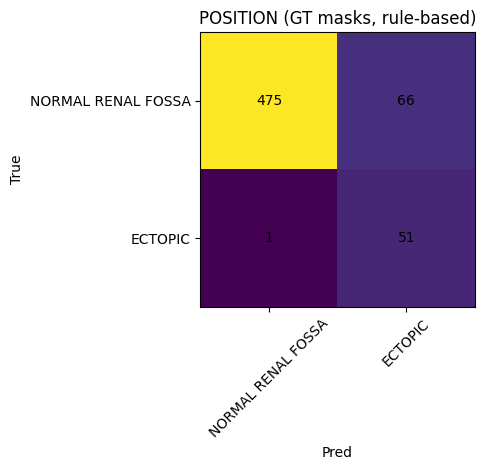

POSITION macro F1 (derived count==2): 0.7609 | per-class: [0.9147, 0.6071]


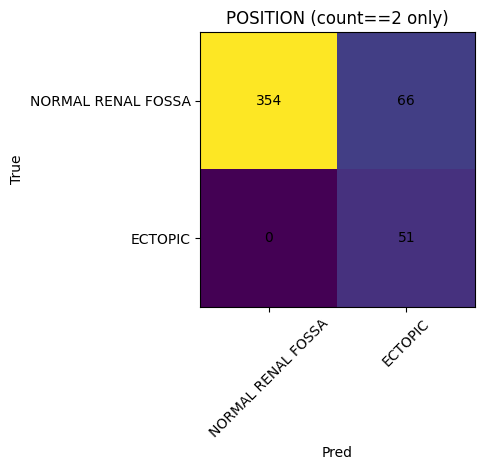

In [10]:
# CELL 23.6 - POSITION head (GT masks only, rule-based, P-dominant)

import numpy as np

POS_LABELS = ["NORMAL RENAL FOSSA", "ECTOPIC"]
POS_TO_I = {s: i for i, s in enumerate(POS_LABELS)}

# Tunable geometry thresholds for "normal" appearance.
SIDE_BY_SIDE_DX_FRAC = 0.55
SAME_AXIS_DY_FRAC = 0.35
CLEAR_GAP_FRAC = 0.10
CLEAR_GAP_PIX = 6
POS_THRESHOLD = 0.50


def _patient_label_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    area = int(xs.size)
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "area": area, "cx": cx, "cy": cy, "w": w, "h": h}


def _view_normal_flags(mL, mR):
    sL = _mask_stats(mL); sR = _mask_stats(mR)
    if sL is None or sR is None:
        return False, {"reason": "missing"}

    # Order by horizontal position (left-to-right).
    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    x_gap = max(0.0, float(b["x0"] - a["x1"] - 1))
    x_overlap = max(0.0, float(min(a["x1"], b["x1"]) - max(a["x0"], b["x0"]) + 1))

    side_by_side = (dx >= SIDE_BY_SIDE_DX_FRAC * max(mean_w, 1.0)) and (dx >= dy)
    same_axis = dy <= SAME_AXIS_DY_FRAC * max(mean_h, 1.0)
    clear_gap = x_gap >= max(CLEAR_GAP_PIX, CLEAR_GAP_FRAC * max(mean_w, 1.0))

    normal = bool(side_by_side and same_axis and clear_gap and x_overlap <= 0.0)
    feats = {
        "dx": float(dx),
        "dy": float(dy),
        "gap": float(x_gap),
        "overlap": float(x_overlap),
        "side_by_side": bool(side_by_side),
        "same_axis": bool(same_axis),
        "clear_gap": bool(clear_gap),
    }
    return normal, feats


def _derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def position_pred_for_pid(pid):
    dcount = _derived_count(pid)

    # Routing rule: derived count == 1 => forced normal renal fossa.
    if dcount <= 1:
        return "NORMAL RENAL FOSSA", {"rule": "count<=1", "dcount": dcount}

    rows = patient_views(pid)
    w = W_POS_ANAT1

    num = 0.0; den = 0.0
    per_view = []
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        is_normal, feats = _view_normal_flags(mL, mR)
        num += float(w[vi]) * float(is_normal)
        den += float(w[vi])
        per_view.append((VIEW_ORDER[vi], bool(is_normal), feats))

    score = (num / den) if den > 0 else 0.0
    pred = "NORMAL RENAL FOSSA" if score >= POS_THRESHOLD else "ECTOPIC"
    return pred, {"score": float(score), "per_view": per_view, "dcount": dcount}


pos_true = []
pos_pred = []
pos_true_c2 = []
pos_pred_c2 = []

for pid in patients:
    row = _patient_label_row(pid)
    gt = norm_str(row.get(COL_POS, ""))
    if gt not in POS_TO_I:
        continue

    pred, info = position_pred_for_pid(pid)
    pos_true.append(POS_TO_I[gt])
    pos_pred.append(POS_TO_I[pred])

    if int(info.get("dcount", 0)) == 2:
        pos_true_c2.append(POS_TO_I[gt])
        pos_pred_c2.append(POS_TO_I[pred])

print("POSITION samples (all):", len(pos_true))
cm_pos = confusion_matrix_np(pos_true, pos_pred, n_classes=len(POS_LABELS))
f1s_pos, f1m_pos = f1_macro_from_cm(cm_pos)
print("POSITION macro F1 (all):", round(f1m_pos, 4), "| per-class:", [round(x, 4) for x in f1s_pos])
plot_cm(cm_pos, "POSITION (GT masks, rule-based)", POS_LABELS)

if len(pos_true_c2):
    cm_pos_c2 = confusion_matrix_np(pos_true_c2, pos_pred_c2, n_classes=len(POS_LABELS))
    f1s_pos_c2, f1m_pos_c2 = f1_macro_from_cm(cm_pos_c2)
    print("POSITION macro F1 (derived count==2):", round(f1m_pos_c2, 4), "| per-class:", [round(x, 4) for x in f1s_pos_c2])
    plot_cm(cm_pos_c2, "POSITION (count==2 only)", POS_LABELS)


ANATOMY samples (all): 593
ANATOMY macro F1 (all): 0.7207 | per-class: [1.0, 0.9147, 0.6602, 0.3077]


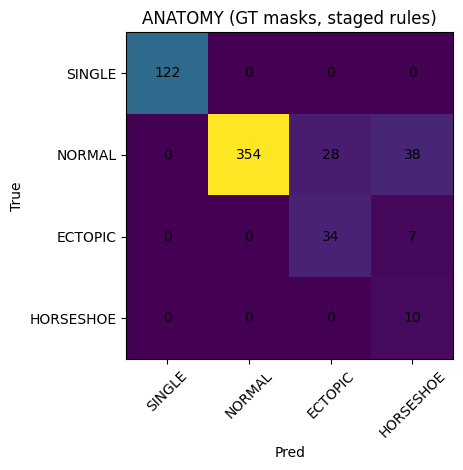

ANATOMY Stage-1 macro F1 (count==2): 0.7609 | per-class: [0.9147, 0.6071]


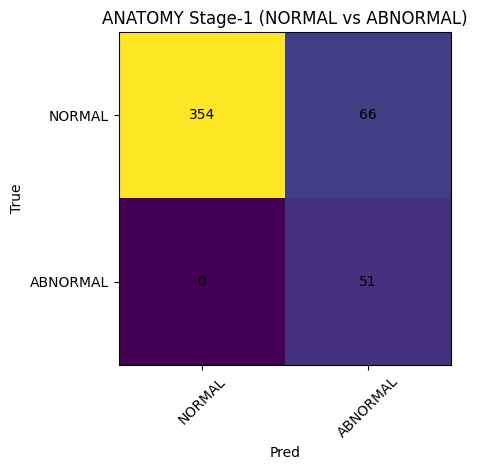

ANATOMY Stage-2 macro F1 (abnormal only): 0.8237 | per-class: [0.9067, 0.7407]


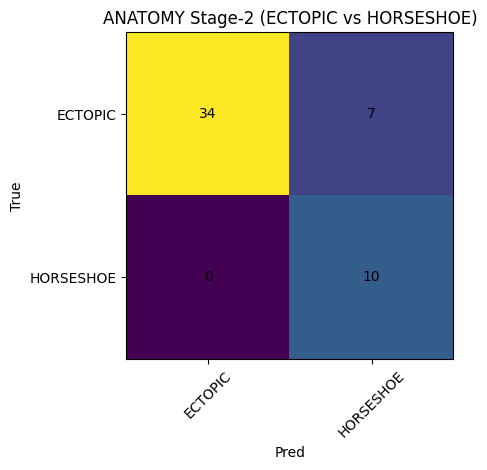

In [11]:
# CELL 23.7 - ANATOMY head (GT masks only, staged rules + classifier-like Stage-2)

import numpy as np

ANAT_LABELS = ["SINGLE", "NORMAL", "ECTOPIC", "HORSESHOE"]
ANAT_TO_I = {s: i for i, s in enumerate(ANAT_LABELS)}
ANAT1_LABELS = ["NORMAL", "ABNORMAL"]
ANAT2_LABELS = ["ECTOPIC", "HORSESHOE"]

# Stage-1 geometry thresholds (same intent as POSITION).
SIDE_BY_SIDE_DX_FRAC = 0.55
SAME_AXIS_DY_FRAC = 0.35
CLEAR_GAP_FRAC = 0.10
CLEAR_GAP_PIX = 6
ANAT1_THRESHOLD = 0.50


def _patient_label_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _norm_anat_label(x):
    s = norm_str(x)
    if s == "HORSHOE":
        s = "HORSESHOE"
    return s


def _mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    area = int(xs.size)
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "area": area, "cx": cx, "cy": cy, "w": w, "h": h}


def _view_pair_features(mL, mR):
    sL = _mask_stats(mL); sR = _mask_stats(mR)
    if sL is None or sR is None:
        return None

    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    x_gap = max(0.0, float(b["x0"] - a["x1"] - 1))
    x_overlap = max(0.0, float(min(a["x1"], b["x1"]) - max(a["x0"], b["x0"]) + 1))

    areaL = float(sL["area"]); areaR = float(sR["area"])
    area_sum = max(areaL + areaR, 1.0)
    area_imb = abs(areaL - areaR) / area_sum

    inter = float(((mL > 0) & (mR > 0)).sum())
    overlap_frac = inter / max(min(areaL, areaR), 1.0)

    union = ((mL > 0) | (mR > 0)).astype(np.uint8)
    union_area = float(union.sum())

    mid_x = int(round(0.5 * (a["cx"] + b["cx"])))
    band_half = int(round(0.25 * max(mean_w, 1.0)))
    x0 = max(0, mid_x - band_half)
    x1 = min(IMG_SIZE, mid_x + band_half + 1)
    bridge_pixels = float(union[:, x0:x1].sum())
    bridge_frac = bridge_pixels / max(union_area, 1.0)

    gap_frac = x_gap / max(mean_w, 1.0)
    dy_frac = dy / max(mean_h, 1.0)

    side_by_side = (dx >= SIDE_BY_SIDE_DX_FRAC * max(mean_w, 1.0)) and (dx >= dy)
    same_axis = dy <= SAME_AXIS_DY_FRAC * max(mean_h, 1.0)
    clear_gap = x_gap >= max(CLEAR_GAP_PIX, CLEAR_GAP_FRAC * max(mean_w, 1.0))

    normal_stage1 = bool(side_by_side and same_axis and clear_gap and x_overlap <= 0.0)

    # Classifier-like fused cue: not a hard rule, just a soft feature.
    fused_like = float((overlap_frac > 0.02) or (bridge_frac > 0.04))

    return {
        "normal_stage1": normal_stage1,
        "overlap_frac": float(overlap_frac),
        "bridge_frac": float(bridge_frac),
        "gap_frac": float(gap_frac),
        "dy_frac": float(dy_frac),
        "area_imb": float(area_imb),
        "fused_like": float(fused_like),
    }


def _derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def anatomy_pred_for_pid(pid):
    dcount = _derived_count(pid)

    # Stage-0 routing rule.
    if dcount <= 1:
        return "SINGLE", {"stage0": "count<=1", "dcount": dcount}

    rows = patient_views(pid)
    w = W_POS_ANAT1

    # Stage-1: NORMAL vs ABNORMAL.
    num = 0.0; den = 0.0
    feats_by_view = []
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        feats = _view_pair_features(mL, mR)
        if feats is None:
            continue
        num += float(w[vi]) * float(feats["normal_stage1"])
        den += float(w[vi])
        feats_by_view.append((vi, feats))

    normal_score = (num / den) if den > 0 else 0.0
    stage1 = "NORMAL" if normal_score >= ANAT1_THRESHOLD else "ABNORMAL"

    if stage1 == "NORMAL":
        return "NORMAL", {"stage1": stage1, "normal_score": float(normal_score), "dcount": dcount}

    # Stage-2: ECTOPIC vs HORSESHOE (soft cues; no single overlap rule).
    horse_num = 0.0; ecto_num = 0.0; den2 = 0.0
    for vi, feats in feats_by_view:
        wi = float(w[vi])
        # Multi-cue scoring: overlap/bridge help horseshoe, while large offset/gap/imbalance help ectopic.
        horse_view = (
            1.8 * feats["overlap_frac"] +
            1.4 * feats["bridge_frac"] +
            0.6 * feats["fused_like"] -
            0.9 * feats["dy_frac"] -
            0.7 * feats["gap_frac"] -
            0.4 * feats["area_imb"]
        )
        ecto_view = (
            1.4 * feats["dy_frac"] +
            1.0 * feats["gap_frac"] +
            0.6 * feats["area_imb"] -
            0.6 * feats["overlap_frac"] -
            0.5 * feats["bridge_frac"]
        )
        horse_num += wi * float(horse_view)
        ecto_num += wi * float(ecto_view)
        den2 += wi

    horse_score = (horse_num / den2) if den2 > 0 else 0.0
    ecto_score = (ecto_num / den2) if den2 > 0 else 0.0

    pred2 = "HORSESHOE" if horse_score >= ecto_score else "ECTOPIC"
    return pred2, {
        "stage1": stage1,
        "normal_score": float(normal_score),
        "horse_score": float(horse_score),
        "ecto_score": float(ecto_score),
        "dcount": dcount,
    }


anat_true = []
anat_pred = []

anat1_true = []
anat1_pred = []

anat2_true = []
anat2_pred = []

for pid in patients:
    row = _patient_label_row(pid)
    gt_full = _norm_anat_label(row.get(COL_ANAT, ""))
    if gt_full not in ANAT_TO_I:
        continue

    pred_full, info = anatomy_pred_for_pid(pid)
    anat_true.append(ANAT_TO_I[gt_full])
    anat_pred.append(ANAT_TO_I[pred_full])

    dcount = int(info.get("dcount", 0))
    if dcount == 2 and gt_full in ("NORMAL", "ECTOPIC", "HORSESHOE"):
        gt_stage1 = "NORMAL" if gt_full == "NORMAL" else "ABNORMAL"
        pred_stage1 = "NORMAL" if pred_full == "NORMAL" else "ABNORMAL"
        anat1_true.append(ANAT1_LABELS.index(gt_stage1))
        anat1_pred.append(ANAT1_LABELS.index(pred_stage1))

        if gt_full in ("ECTOPIC", "HORSESHOE") and pred_stage1 == "ABNORMAL":
            anat2_true.append(ANAT2_LABELS.index(gt_full))
            anat2_pred.append(ANAT2_LABELS.index(pred_full))

print("ANATOMY samples (all):", len(anat_true))
cm_anat = confusion_matrix_np(anat_true, anat_pred, n_classes=len(ANAT_LABELS))
f1s_anat, f1m_anat = f1_macro_from_cm(cm_anat)
print("ANATOMY macro F1 (all):", round(f1m_anat, 4), "| per-class:", [round(x, 4) for x in f1s_anat])
plot_cm(cm_anat, "ANATOMY (GT masks, staged rules)", ANAT_LABELS)

if len(anat1_true):
    cm_anat1 = confusion_matrix_np(anat1_true, anat1_pred, n_classes=len(ANAT1_LABELS))
    f1s_anat1, f1m_anat1 = f1_macro_from_cm(cm_anat1)
    print("ANATOMY Stage-1 macro F1 (count==2):", round(f1m_anat1, 4), "| per-class:", [round(x, 4) for x in f1s_anat1])
    plot_cm(cm_anat1, "ANATOMY Stage-1 (NORMAL vs ABNORMAL)", ANAT1_LABELS)

if len(anat2_true):
    cm_anat2 = confusion_matrix_np(anat2_true, anat2_pred, n_classes=len(ANAT2_LABELS))
    f1s_anat2, f1m_anat2 = f1_macro_from_cm(cm_anat2)
    print("ANATOMY Stage-2 macro F1 (abnormal only):", round(f1m_anat2, 4), "| per-class:", [round(x, 4) for x in f1s_anat2])
    plot_cm(cm_anat2, "ANATOMY Stage-2 (ECTOPIC vs HORSESHOE)", ANAT2_LABELS)


In [12]:
# CELL 23.5 - Post-seg model architecture (ConvNeXt-Tiny, 4-ch, 3-view weighted fusion)

import torch
import torch.nn as nn
import timm

class ConvNeXtHead(nn.Module):
    """
    Post-seg head:
    - backbone: MODEL_NAME (timm), pretrained
    - input: 4-channel images (I, I*mask, mask, I*(1-mask))
    - view fusion: weighted sum across 3 views (P/LPO/RPO)
    - extra features: configurable feat_dim appended before FC
    """
    def __init__(self, n_classes, feat_dim=3):
        super().__init__()
        self.feat_dim = int(feat_dim)
        self.backbone = timm.create_model(
            MODEL_NAME,
            pretrained=True,
            in_chans=4,
            num_classes=0,
            global_pool="avg",
        )
        self.fc = nn.Sequential(
            nn.Linear(self.backbone.num_features + self.feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes),
        )

    def forward(self, x3v, feat, w):
        # x3v: [B,3,4,H,W], feat: [B,feat_dim], w: [3]
        logits = 0
        for vi in range(3):
            f = self.backbone(x3v[:, vi])
            f = torch.cat([f, feat], dim=1)
            lv = self.fc(f)
            logits = logits + float(w[vi]) * lv
        return logits


POSITION valid train (count==2): 380
POSITION valid val   (count==2): 42
POSITION valid test  (count==2): 49
POSITION oversampled train ids: 646


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
C:\Users\Rashed Fahim\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Rashed Fahim\.cache\huggingface\hub\models--timm--convnext_tiny.in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activat

[POSITION] ep 01 | train loss 0.7352 f1m 0.5045 n 646 | val loss 0.4685 f1m 0.4750 n 42 | 98.7s


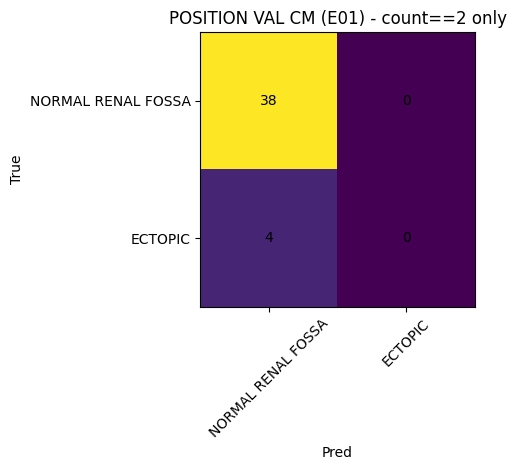

POSITION saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_POSITION_gtmask.pt | best: 0.475


[POSITION] ep 02 | train loss 0.6667 f1m 0.6096 n 646 | val loss 0.5052 f1m 0.4750 n 42 | 127.1s


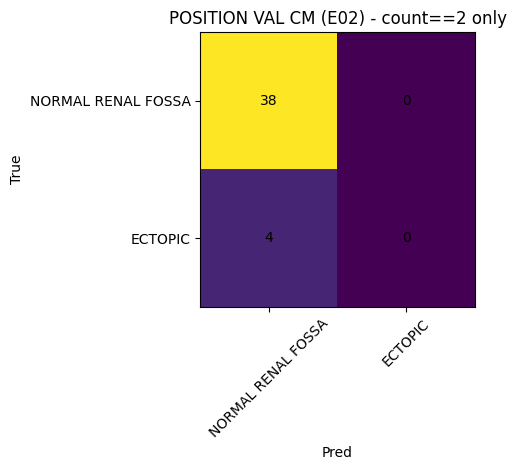

POSITION no improve. bad: 1 / 7


[POSITION] ep 03 | train loss 0.6294 f1m 0.6723 n 646 | val loss 0.5657 f1m 1.0000 n 42 | 115.1s


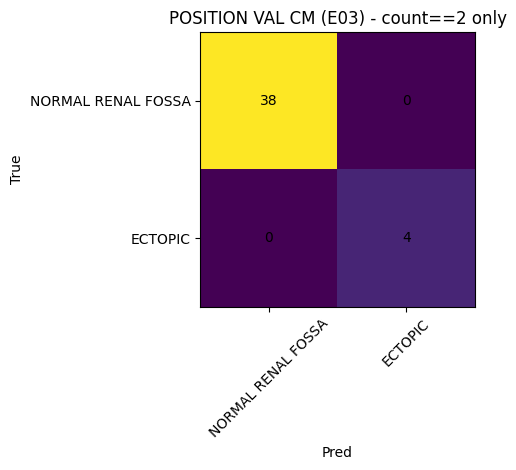

POSITION saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_POSITION_gtmask.pt | best: 1.0


[POSITION] ep 04 | train loss 0.5573 f1m 0.8308 n 646 | val loss 0.5327 f1m 0.9378 n 42 | 117.5s


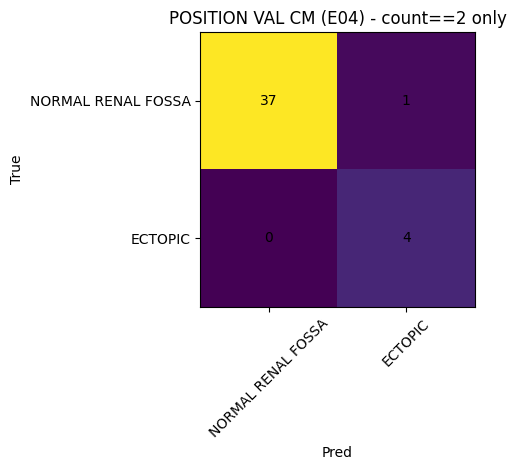

POSITION no improve. bad: 1 / 7


[POSITION] ep 05 | train loss 0.4860 f1m 0.8588 n 646 | val loss 0.3676 f1m 1.0000 n 42 | 118.0s


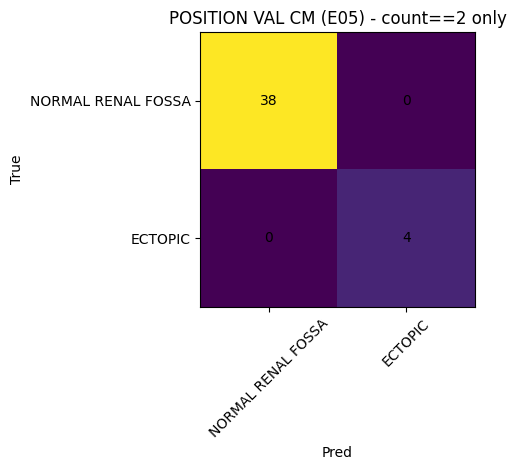

POSITION no improve. bad: 2 / 7


[POSITION] ep 06 | train loss 0.3979 f1m 0.8923 n 646 | val loss 0.3740 f1m 0.9378 n 42 | 115.3s


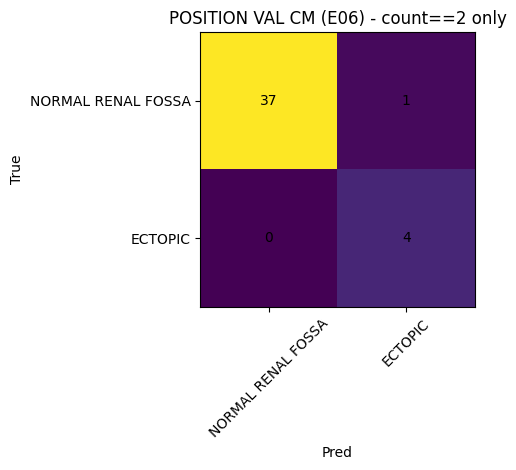

POSITION no improve. bad: 3 / 7


[POSITION] ep 07 | train loss 0.3410 f1m 0.9052 n 646 | val loss 0.2772 f1m 1.0000 n 42 | 115.1s


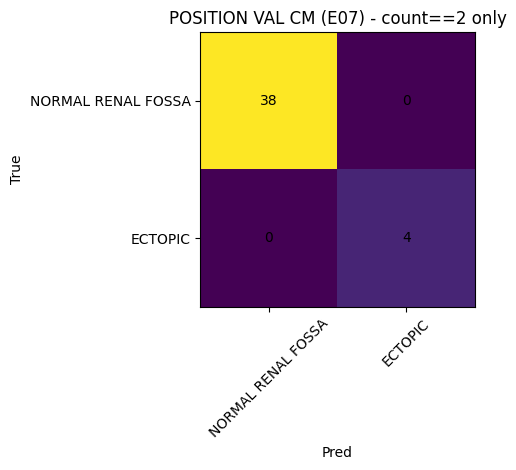

POSITION no improve. bad: 4 / 7


[POSITION] ep 08 | train loss 0.2910 f1m 0.9119 n 646 | val loss 0.1868 f1m 1.0000 n 42 | 129.6s


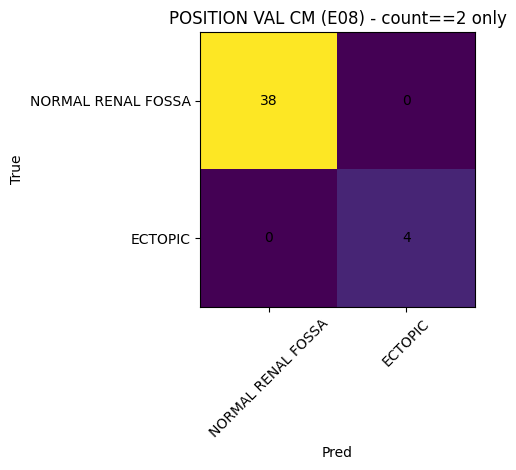

POSITION no improve. bad: 5 / 7


[POSITION] ep 09 | train loss 0.2555 f1m 0.9167 n 646 | val loss 0.1418 f1m 1.0000 n 42 | 114.0s


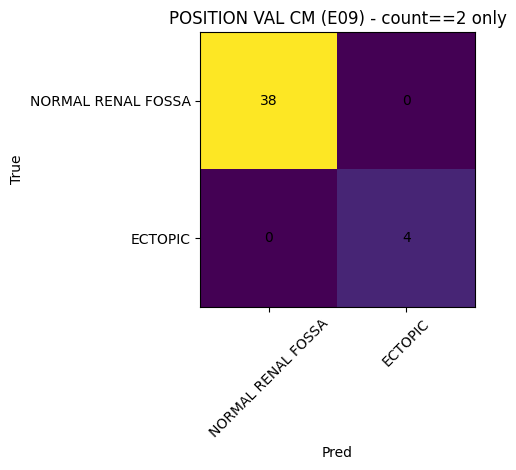

POSITION no improve. bad: 6 / 7


[POSITION] ep 10 | train loss 0.2301 f1m 0.9152 n 646 | val loss 0.1897 f1m 0.9378 n 42 | 111.3s


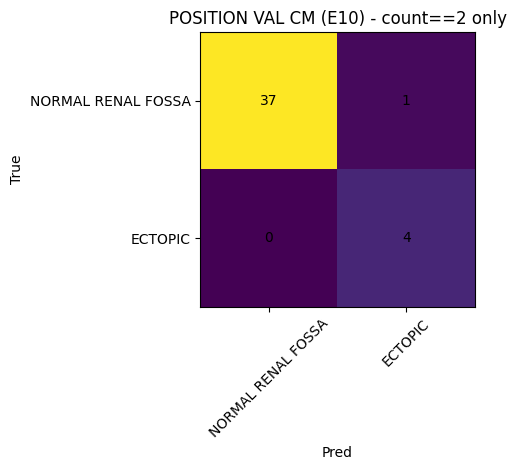

POSITION no improve. bad: 7 / 7
POSITION early stop at ep 10
POSITION reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_POSITION_gtmask.pt | epoch: 3 | best: 1.0
POSITION macro F1 (with gating): 0.9279 | per-class: [0.9808, 0.875]


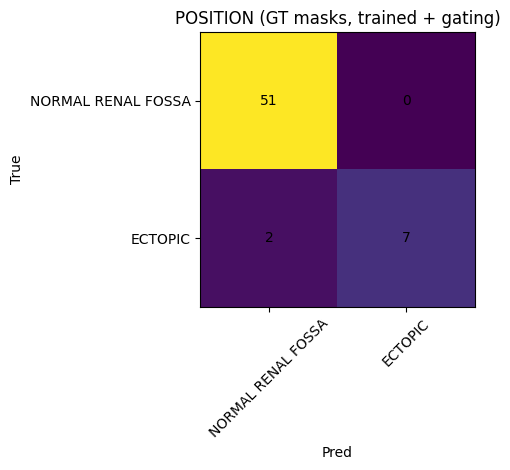

POSITION macro F1 (count==2 only): 0.9253 | per-class: [0.9756, 0.875]


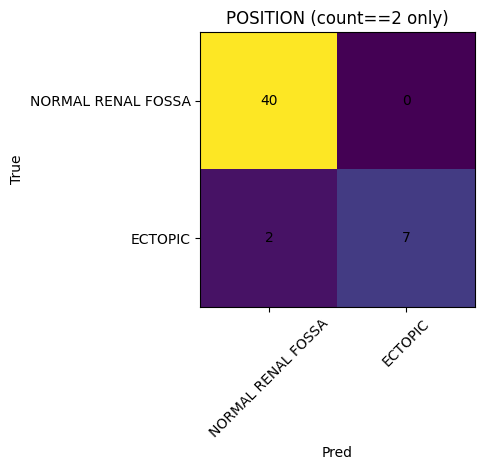

In [13]:
# CELL 23.8 - POSITION head training (GT masks, gated on derived count==2)

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

POS2 = ["NORMAL RENAL FOSSA", "ECTOPIC"]
POS_TO_I = {s: i for i, s in enumerate(POS2)}


def _pos_patient_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _pos_norm_label(x):
    return norm_str(x)


def _pos_mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    area = float(xs.size)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "cx": cx, "cy": cy, "w": w, "h": h, "area": area}


def _pos_pair_geom(mL, mR):
    sL = _pos_mask_stats(mL); sR = _pos_mask_stats(mR)
    if sL is None or sR is None:
        return None

    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)
    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])
    gap = max(0.0, float(b["x0"] - a["x1"] - 1))

    dx_norm = dx / max(mean_w, 1.0)
    dy_norm = dy / max(mean_h, 1.0)
    gap_norm = gap / max(mean_w, 1.0)
    return np.array([dx_norm, dy_norm, gap_norm], dtype=np.float32)


def _pos_feat_for_pid(pid):
    rows = patient_views(pid)
    w = W_POS_ANAT1.astype(np.float32)
    acc = np.zeros((3,), dtype=np.float32)
    den = 0.0
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        f = _pos_pair_geom(mL, mR)
        if f is None:
            continue
        acc += float(w[vi]) * f
        den += float(w[vi])
    return (acc / den) if den > 0 else acc


def _pos_derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def _pos_valid_label_for_pid(pid):
    row = _pos_patient_row(pid)
    gt = _pos_norm_label(row.get(COL_POS, ""))
    if gt not in POS_TO_I:
        return None
    if _pos_derived_count(pid) != 2:
        return None
    return gt


def _count_pos_valid(pids):
    n = 0
    for pid in pids:
        if _pos_valid_label_for_pid(pid) is not None:
            n += 1
    return n


class PositionDataset(Dataset):
    def __init__(self, pids):
        self.pids = list(pids)

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3, 4, IMG_SIZE, IMG_SIZE), dtype=np.float32)
        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)
            X[vi] = build_input4(I, mL, mR, mode="GEN")

        feat = _pos_feat_for_pid(pid).astype(np.float32)

        gt = _pos_valid_label_for_pid(pid)
        if gt is None:
            y = -1; valid = 0
        else:
            y = POS_TO_I[gt]; valid = 1

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "dcount": torch.tensor(int(_pos_derived_count(pid)), dtype=torch.long),
        }


def make_position_train_pids():
    mult_map = OVERSAMPLE.get("POSITION", {})
    out = []
    for pid in train_p:
        gt = _pos_valid_label_for_pid(pid)
        if gt is None:
            continue
        mult = int(mult_map.get(gt, 1))
        mult = max(mult, 1)
        for _ in range(mult):
            out.append(pid)
    return out


def _run_pos_epoch(model, loader, opt=None):
    is_train = opt is not None
    model.train(is_train)
    ce = nn.CrossEntropyLoss()

    total_loss = 0.0
    n = 0
    y_true = []
    y_pred = []

    w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)

    for batch in tqdm(loader, leave=False):
        valid = batch["valid"].to(DEVICE).bool()
        if not bool(valid.any()):
            continue

        x = batch["x"].to(DEVICE)[valid]
        feat = batch["feat"].to(DEVICE)[valid]
        y = batch["y"].to(DEVICE)[valid]

        logits = model(x, feat, w)
        loss = ce(logits, y)

        if is_train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        bs = int(y.size(0))
        total_loss += float(loss.item()) * bs
        n += bs

        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

    if n == 0:
        cm = np.zeros((len(POS2), len(POS2)), dtype=np.int64)
        return {"loss": float("nan"), "f1m": 0.0, "cm": cm, "n": 0}

    cm = confusion_matrix_np(y_true, y_pred, n_classes=len(POS2))
    f1s, f1m = f1_macro_from_cm(cm)
    return {"loss": total_loss / max(n, 1), "f1m": float(f1m), "cm": cm, "f1s": f1s, "n": n}


def position_infer_pid(model, pid):
    dcount = _pos_derived_count(pid)
    if dcount <= 1:
        return "NORMAL RENAL FOSSA", {"rule": "count<=1", "dcount": dcount}

    sample = PositionDataset([pid])[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return POS2[pred_i], {"dcount": dcount}


pos_tr_ids = make_position_train_pids()
pos_val_ids = list(val_p)
pos_test_ids = list(test_p)

print("POSITION valid train (count==2):", _count_pos_valid(train_p))
print("POSITION valid val   (count==2):", _count_pos_valid(val_p))
print("POSITION valid test  (count==2):", _count_pos_valid(test_p))
print("POSITION oversampled train ids:", len(pos_tr_ids))

pos_tr_ds = PositionDataset(pos_tr_ids)
pos_va_ds = PositionDataset(pos_val_ids)

pos_tr_loader = DataLoader(pos_tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
pos_va_loader = DataLoader(pos_va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

pos_model = ConvNeXtHead(n_classes=len(POS2)).to(DEVICE)
pos_opt = torch.optim.AdamW(pos_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_path = BASE_DIR / "best_POSITION_gtmask.pt"
# Safe init so reload always works even if val has 0 eligible samples.
torch.save({"model": pos_model.state_dict(), "epoch": 0, "best": -1.0}, best_path)
best = -1.0
bad = 0

for ep in range(1, int(EPOCHS) + 1):
    t0 = time.time()
    tr_m = _run_pos_epoch(pos_model, pos_tr_loader, opt=pos_opt)
    va_m = _run_pos_epoch(pos_model, pos_va_loader, opt=None)

    if va_m["n"] == 0:
        bad += 1
        print(
            f"[POSITION] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
            f" | VAL has 0 eligible samples (count==2) | bad {bad}/{PATIENCE} | {time.time()-t0:.1f}s"
        )
        if EARLY_STOP_ON and bad >= int(PATIENCE):
            print("POSITION early stop (no val samples) at ep", ep)
            break
        continue

    metric = float(va_m["f1m"])

    print(
        f"[POSITION] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
        f" | val loss {va_m['loss']:.4f} f1m {va_m['f1m']:.4f} n {va_m['n']} | {time.time()-t0:.1f}s"
    )
    plot_cm(va_m["cm"], f"POSITION VAL CM (E{ep:02d}) - count==2 only", POS2)

    if metric > best + float(MIN_DELTA):
        best = metric
        bad = 0
        torch.save({"model": pos_model.state_dict(), "epoch": ep, "best": best}, best_path)
        print("POSITION saved best:", best_path, "| best:", best)
    else:
        bad += 1
        print("POSITION no improve. bad:", bad, "/", PATIENCE)
        if EARLY_STOP_ON and bad >= int(PATIENCE):
            print("POSITION early stop at ep", ep)
            break

ck = torch.load(best_path, map_location=DEVICE)
pos_model.load_state_dict(ck["model"])
pos_model.eval()
print("POSITION reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))


def eval_position_with_gate(model, pids):
    y_true = []
    y_pred = []
    y_true_c2 = []
    y_pred_c2 = []

    for pid in pids:
        row = _pos_patient_row(pid)
        gt = _pos_norm_label(row.get(COL_POS, ""))
        if gt not in POS_TO_I:
            continue

        dcount = _pos_derived_count(pid)
        if dcount <= 1:
            pred = "NORMAL RENAL FOSSA"
        else:
            pred, _ = position_infer_pid(model, pid)

        y_true.append(POS_TO_I[gt])
        y_pred.append(POS_TO_I[pred])

        if dcount == 2:
            y_true_c2.append(POS_TO_I[gt])
            y_pred_c2.append(POS_TO_I[pred])

    cm_all = confusion_matrix_np(y_true, y_pred, n_classes=len(POS2))
    f1s_all, f1m_all = f1_macro_from_cm(cm_all)
    print("POSITION macro F1 (with gating):", round(f1m_all, 4), "| per-class:", [round(x, 4) for x in f1s_all])
    plot_cm(cm_all, "POSITION (GT masks, trained + gating)", POS2)

    if len(y_true_c2):
        cm_c2 = confusion_matrix_np(y_true_c2, y_pred_c2, n_classes=len(POS2))
        f1s_c2, f1m_c2 = f1_macro_from_cm(cm_c2)
        print("POSITION macro F1 (count==2 only):", round(f1m_c2, 4), "| per-class:", [round(x, 4) for x in f1s_c2])
        plot_cm(cm_c2, "POSITION (count==2 only)", POS2)


eval_position_with_gate(pos_model, pos_test_ids)


ANAT1 valid train (count==2): 380
ANAT1 valid val   (count==2): 42
ANAT1 oversampled train ids: 646


[ANAT1] ep 01 | train loss 0.7277 f1m 0.5028 n 646 | val loss 0.6140 f1m 0.4750 n 42 | 84.0s


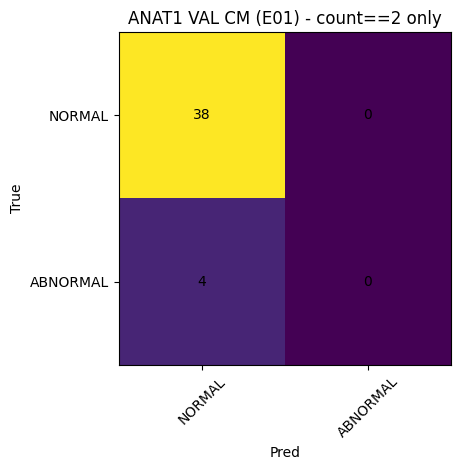

ANAT1 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT1_gtmask.pt | best: 0.475


[ANAT1] ep 02 | train loss 0.6489 f1m 0.6193 n 646 | val loss 0.4540 f1m 0.4750 n 42 | 177.5s


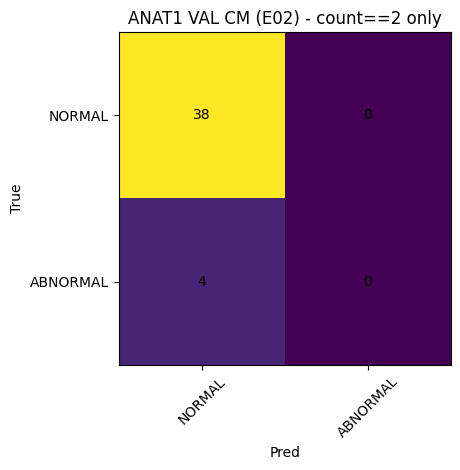

ANAT1 no improve. bad: 1 / 7


[ANAT1] ep 03 | train loss 0.5926 f1m 0.8023 n 646 | val loss 0.3835 f1m 0.6810 n 42 | 179.3s


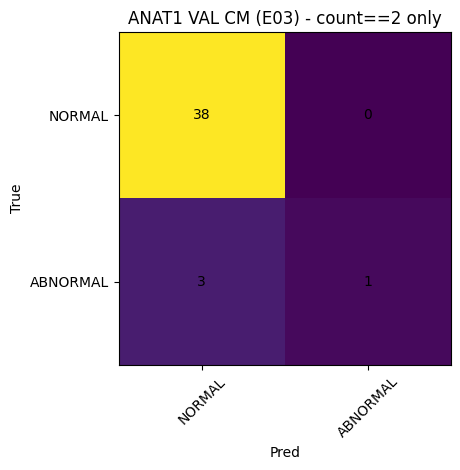

ANAT1 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT1_gtmask.pt | best: 0.6810126582278482


[ANAT1] ep 04 | train loss 0.5137 f1m 0.8152 n 646 | val loss 0.4066 f1m 1.0000 n 42 | 170.6s


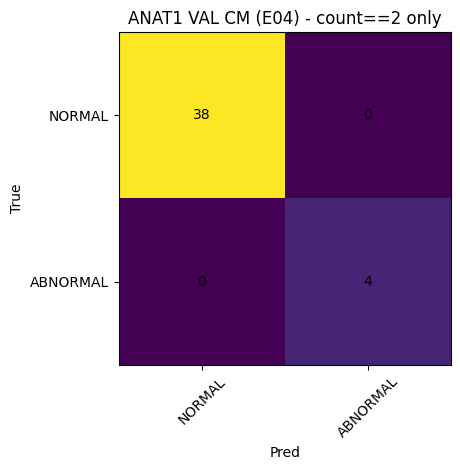

ANAT1 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT1_gtmask.pt | best: 1.0


[ANAT1] ep 05 | train loss 0.4165 f1m 0.8904 n 646 | val loss 0.2864 f1m 1.0000 n 42 | 184.7s


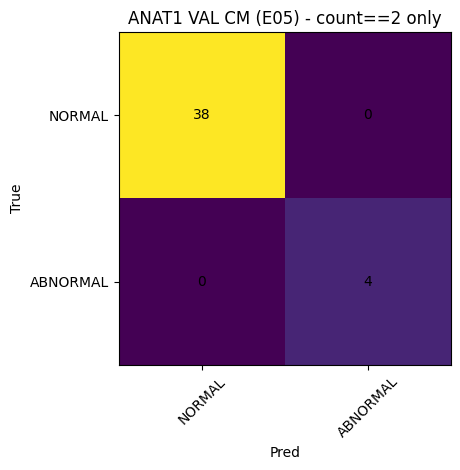

ANAT1 no improve. bad: 1 / 7


[ANAT1] ep 06 | train loss 0.3388 f1m 0.9090 n 646 | val loss 0.1800 f1m 1.0000 n 42 | 167.2s


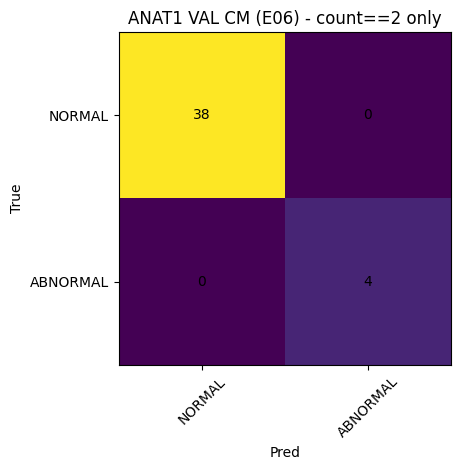

ANAT1 no improve. bad: 2 / 7


[ANAT1] ep 07 | train loss 0.2960 f1m 0.9105 n 646 | val loss 0.1431 f1m 1.0000 n 42 | 170.4s


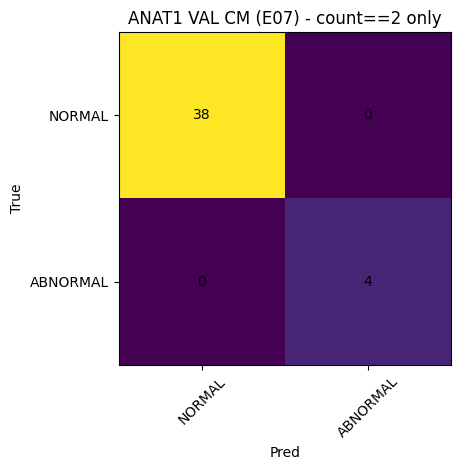

ANAT1 no improve. bad: 3 / 7


[ANAT1] ep 08 | train loss 0.2701 f1m 0.8947 n 646 | val loss 0.1572 f1m 1.0000 n 42 | 164.5s


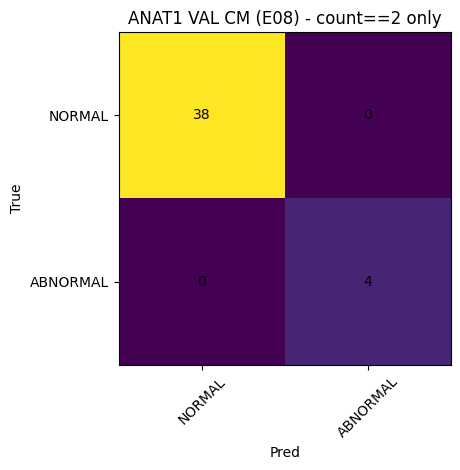

ANAT1 no improve. bad: 4 / 7


[ANAT1] ep 09 | train loss 0.2390 f1m 0.9250 n 646 | val loss 0.2215 f1m 0.8865 n 42 | 164.2s


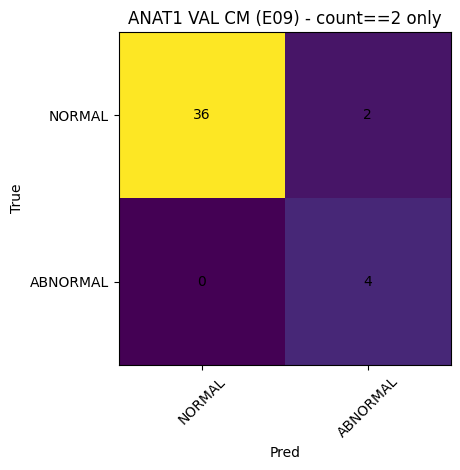

ANAT1 no improve. bad: 5 / 7


[ANAT1] ep 10 | train loss 0.2260 f1m 0.9109 n 646 | val loss 0.1494 f1m 0.9378 n 42 | 163.9s


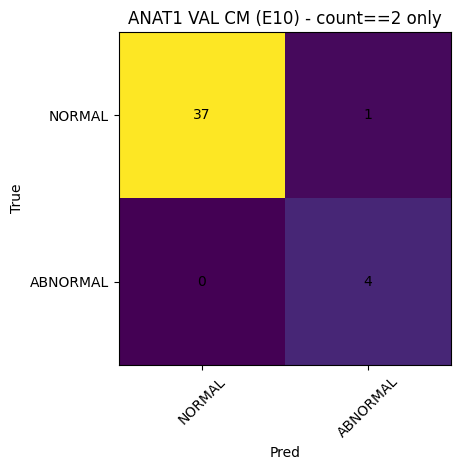

ANAT1 no improve. bad: 6 / 7


[ANAT1] ep 11 | train loss 0.2017 f1m 0.9359 n 646 | val loss 0.1710 f1m 0.9378 n 42 | 162.9s


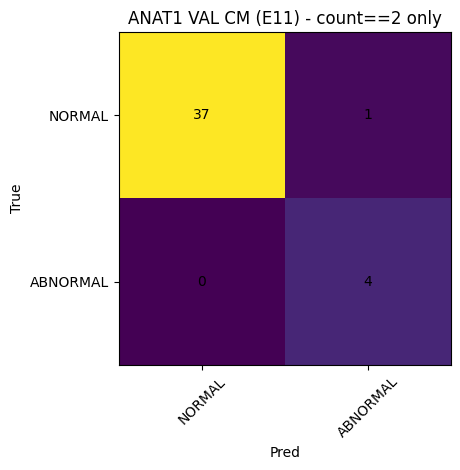

ANAT1 no improve. bad: 7 / 7
ANAT1 early stop at ep 11
ANAT1 reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT1_gtmask.pt | epoch: 4 | best: 1.0
ANAT2 valid train (count==2): 38
ANAT2 valid val   (count==2): 4
ANAT2 oversampled train ids: 380


[ANAT2] ep 01 | train loss 0.7142 f1m 0.4985 n 380 | val loss 0.8045 f1m 0.0000 n 4 | 107.1s


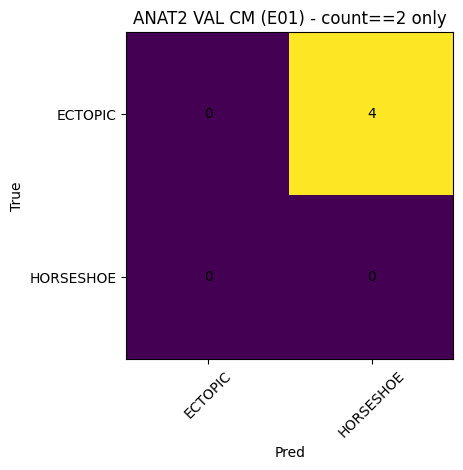

ANAT2 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT2_gtmask.pt | best: 0.0


[ANAT2] ep 02 | train loss 0.6963 f1m 0.5125 n 380 | val loss 1.0211 f1m 0.0000 n 4 | 51.8s


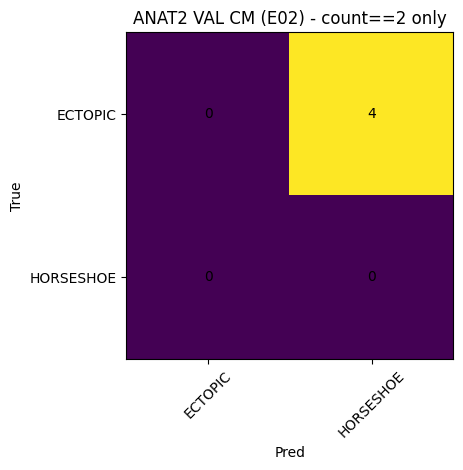

ANAT2 no improve. bad: 1 / 7


[ANAT2] ep 03 | train loss 0.6924 f1m 0.5119 n 380 | val loss 0.7412 f1m 0.0000 n 4 | 51.6s


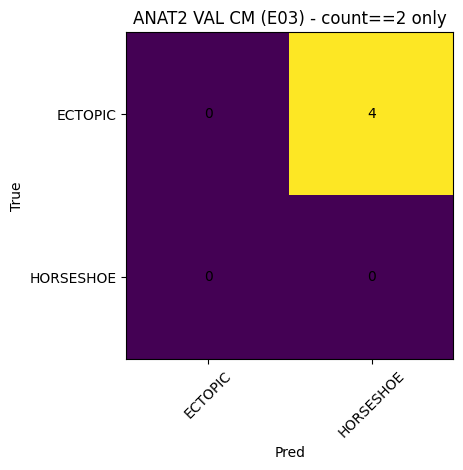

ANAT2 no improve. bad: 2 / 7


[ANAT2] ep 04 | train loss 0.6681 f1m 0.6143 n 380 | val loss 0.6961 f1m 0.3333 n 4 | 51.3s


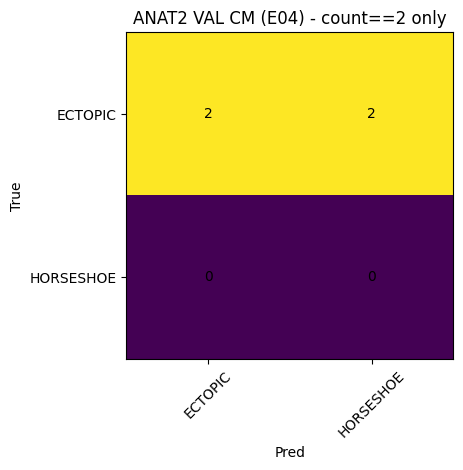

ANAT2 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT2_gtmask.pt | best: 0.3333333333333333


[ANAT2] ep 05 | train loss 0.6659 f1m 0.5662 n 380 | val loss 0.5997 f1m 0.5000 n 4 | 51.0s


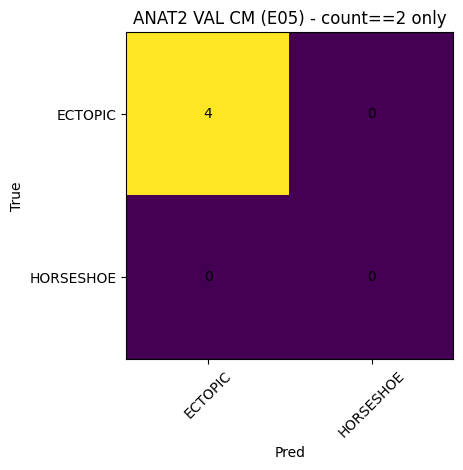

ANAT2 saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT2_gtmask.pt | best: 0.5


[ANAT2] ep 06 | train loss 0.6377 f1m 0.6123 n 380 | val loss 0.7057 f1m 0.3333 n 4 | 51.3s


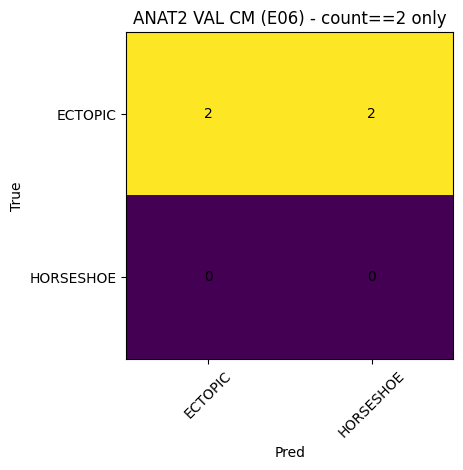

ANAT2 no improve. bad: 1 / 7


[ANAT2] ep 07 | train loss 0.6091 f1m 0.7934 n 380 | val loss 0.7431 f1m 0.2000 n 4 | 51.1s


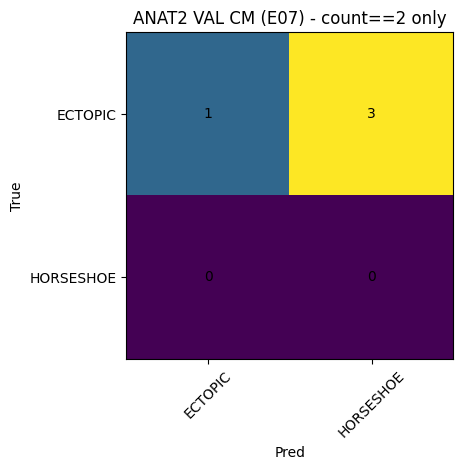

ANAT2 no improve. bad: 2 / 7


[ANAT2] ep 08 | train loss 0.5829 f1m 0.8109 n 380 | val loss 0.6242 f1m 0.4286 n 4 | 51.3s


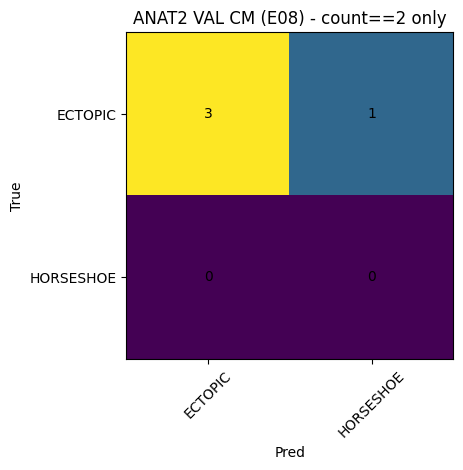

ANAT2 no improve. bad: 3 / 7


[ANAT2] ep 09 | train loss 0.5430 f1m 0.8554 n 380 | val loss 0.7726 f1m 0.2000 n 4 | 51.2s


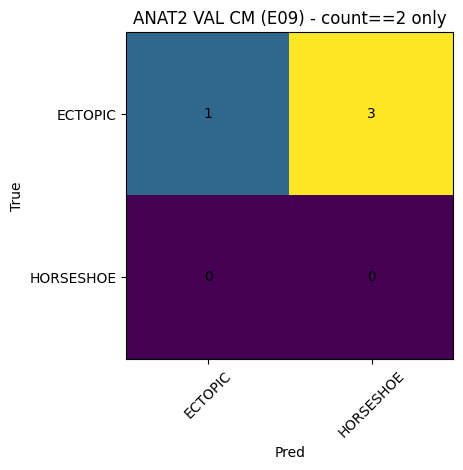

ANAT2 no improve. bad: 4 / 7


[ANAT2] ep 10 | train loss 0.5157 f1m 0.8295 n 380 | val loss 0.7233 f1m 0.3333 n 4 | 51.1s


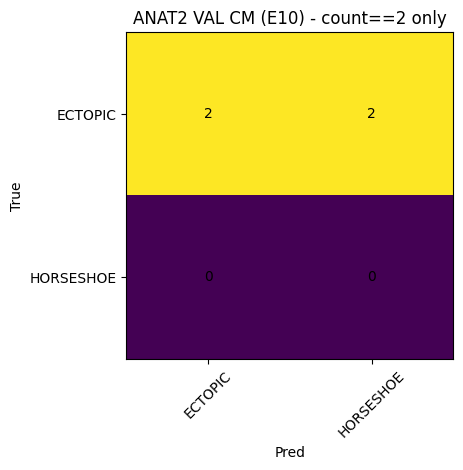

ANAT2 no improve. bad: 5 / 7


[ANAT2] ep 11 | train loss 0.4761 f1m 0.8934 n 380 | val loss 0.6760 f1m 0.3333 n 4 | 51.2s


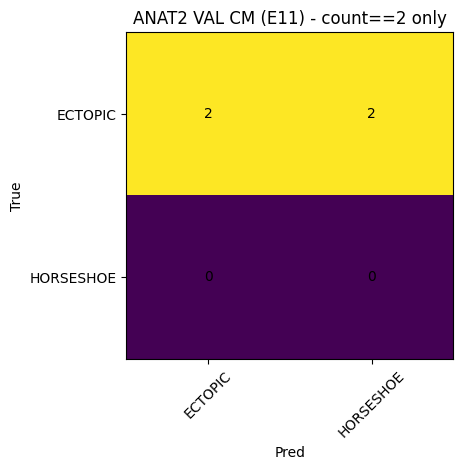

ANAT2 no improve. bad: 6 / 7


[ANAT2] ep 12 | train loss 0.4330 f1m 0.9059 n 380 | val loss 0.5382 f1m 0.4286 n 4 | 51.9s


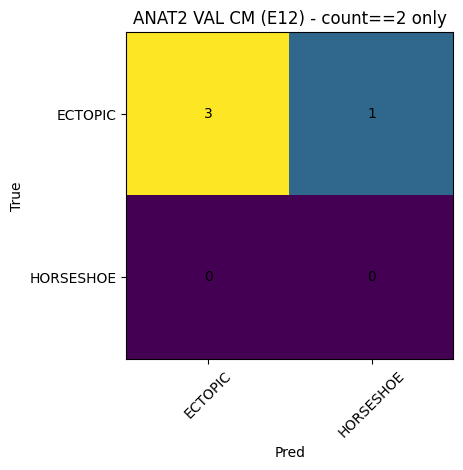

ANAT2 no improve. bad: 7 / 7
ANAT2 early stop at ep 12
ANAT2 reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_ANAT2_gtmask.pt | epoch: 5 | best: 0.5
ANATOMY macro F1 (with gating): 0.6725 | per-class: [1.0, 0.9756, 0.7143, 0.0]


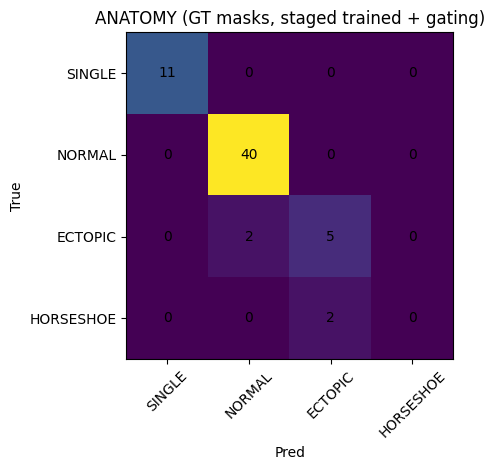

ANATOMY Stage-1 macro F1 (count==2): 0.9253 | per-class: [0.9756, 0.875]


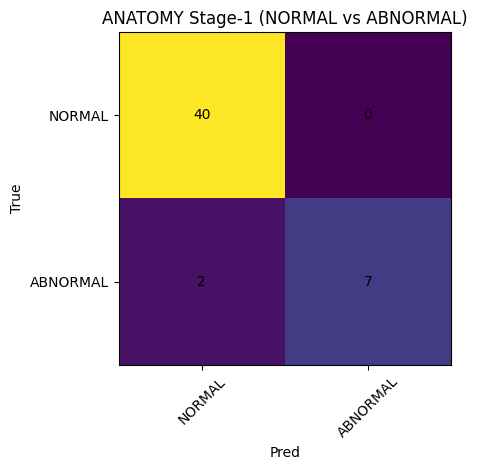

ANATOMY Stage-2 macro F1 (abnormal only): 0.4167 | per-class: [0.8333, 0.0]


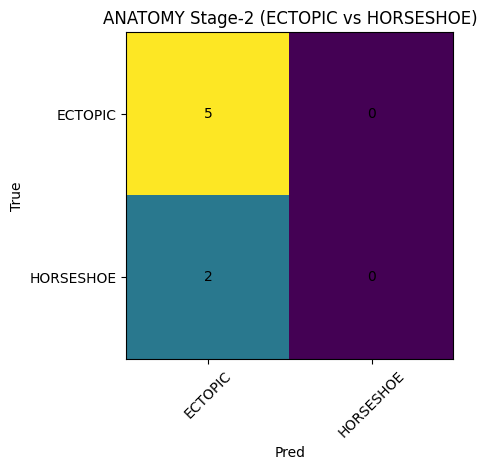

In [14]:
# CELL 23.9 - ANATOMY staged training (GT masks, gated on derived count==2, geometry features)

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

ANAT_LABELS = ["SINGLE", "NORMAL", "ECTOPIC", "HORSESHOE"]
ANAT_TO_I = {s: i for i, s in enumerate(ANAT_LABELS)}
ANAT1_LABELS = ["NORMAL", "ABNORMAL"]
ANAT2_LABELS = ["ECTOPIC", "HORSESHOE"]

ANAT_FEAT_DIM = 7


def _anat_patient_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _anat_norm_label(x):
    s = norm_str(x)
    if s == "HORSHOE":
        s = "HORSESHOE"
    return s


def _anat_derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def _anat_mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    area = float(xs.size)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "cx": cx, "cy": cy, "w": w, "h": h, "area": area}


def _anat_geom_features_from_masks(mL, mR):
    sL = _anat_mask_stats(mL); sR = _anat_mask_stats(mR)
    if sL is None or sR is None:
        return None

    # Order kidneys left-to-right by centroid x to make gap/bridge consistent.
    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    gap = max(0.0, float(b["x0"] - a["x1"] - 1))

    dx_norm = dx / max(mean_w, 1.0)
    dy_norm = dy / max(mean_h, 1.0)
    gap_norm = gap / max(mean_w, 1.0)

    areaL = float(sL["area"]); areaR = float(sR["area"])
    area_sum = max(areaL + areaR, 1.0)
    area_imb = abs(areaL - areaR) / area_sum

    inter = float(((mL > 0) & (mR > 0)).sum())
    overlap_frac = inter / max(min(areaL, areaR), 1.0)

    union = ((mL > 0) | (mR > 0)).astype(np.uint8)
    union_area = float(union.sum())

    mid_x = int(round(0.5 * (a["cx"] + b["cx"])))
    band_half = max(1, int(round(0.25 * max(mean_w, 1.0))))
    x0 = max(0, mid_x - band_half)
    x1 = min(IMG_SIZE, mid_x + band_half + 1)
    bridge_pixels = float(union[:, x0:x1].sum())
    bridge_frac = bridge_pixels / max(union_area, 1.0)

    # Soft fusion cue (not a hard rule): overlap/bridge can suggest horseshoe.
    fused_like = 1.0 if (overlap_frac > 0.02 or bridge_frac > 0.04) else 0.0

    return np.array(
        [dx_norm, dy_norm, gap_norm, overlap_frac, bridge_frac, area_imb, fused_like],
        dtype=np.float32,
    )


def _anat_weighted_fuse_view_feats(per_view_feats, w, view_valid):
    w = np.asarray(w, dtype=np.float32).reshape(-1)
    vv = np.asarray(view_valid, dtype=np.float32).reshape(-1)
    ww = w * vv
    den = float(ww.sum())
    if den <= 0:
        return np.zeros((per_view_feats.shape[1],), dtype=np.float32)
    return (per_view_feats * ww[:, None]).sum(axis=0) / den


def _anat_feat_for_pid(pid):
    rows = patient_views(pid)
    per_view_feats = np.zeros((3, ANAT_FEAT_DIM), dtype=np.float32)
    view_valid = np.zeros((3,), dtype=np.float32)

    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        if int(mL.sum()) == 0 or int(mR.sum()) == 0:
            continue
        f = _anat_geom_features_from_masks(mL, mR)
        if f is None:
            continue
        per_view_feats[vi] = f
        view_valid[vi] = 1.0

    return _anat_weighted_fuse_view_feats(per_view_feats, W_POS_ANAT1, view_valid)


def _anat_stage1_label(full_label):
    if full_label == "NORMAL":
        return "NORMAL"
    if full_label in ("ECTOPIC", "HORSESHOE"):
        return "ABNORMAL"
    return None


def _anat_stage2_label(full_label):
    if full_label in ANAT2_LABELS:
        return full_label
    return None


def _anat_valid_label_for_pid(pid, stage):
    if _anat_derived_count(pid) != 2:
        return None
    row = _anat_patient_row(pid)
    full = _anat_norm_label(row.get(COL_ANAT, ""))
    if full not in ANAT_TO_I:
        return None
    if stage == "ANAT1":
        return _anat_stage1_label(full)
    if stage == "ANAT2":
        return _anat_stage2_label(full)
    return None


def _count_anat_valid(pids, stage):
    n = 0
    for pid in pids:
        if _anat_valid_label_for_pid(pid, stage) is not None:
            n += 1
    return n


class AnatomyStageDataset(Dataset):
    def __init__(self, pids, stage):
        self.pids = list(pids)
        self.stage = stage

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3, 4, IMG_SIZE, IMG_SIZE), dtype=np.float32)
        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)
            X[vi] = build_input4(I, mL, mR, mode="GEN")

        feat = _anat_feat_for_pid(pid).astype(np.float32)

        lab = _anat_valid_label_for_pid(pid, self.stage)
        if lab is None:
            y = -1; valid = 0
        else:
            if self.stage == "ANAT1":
                y = ANAT1_LABELS.index(lab)
            else:
                y = ANAT2_LABELS.index(lab)
            valid = 1

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "dcount": torch.tensor(int(_anat_derived_count(pid)), dtype=torch.long),
        }


def make_anat_train_pids(stage):
    out = []
    if stage == "ANAT1":
        mult_map = OVERSAMPLE.get("POSITION", {})
    else:
        mult_map = OVERSAMPLE.get("ANAT2", {})

    for pid in train_p:
        lab = _anat_valid_label_for_pid(pid, stage)
        if lab is None:
            continue

        if stage == "ANAT1":
            key = "NORMAL RENAL FOSSA" if lab == "NORMAL" else "ECTOPIC"
            mult = int(mult_map.get(key, 1))
        else:
            if lab == "HORSESHOE":
                if "HORSESHOE" in mult_map:
                    mult = int(mult_map.get("HORSESHOE", 1))
                elif "HORSHOE" in mult_map:
                    mult = int(mult_map.get("HORSHOE", 1))
                else:
                    mult = int(mult_map.get(lab, 1))
            else:
                mult = int(mult_map.get(lab, 1))

        mult = max(mult, 1)
        for _ in range(mult):
            out.append(pid)
    return out


def _run_anat_epoch(model, loader, stage, opt=None):
    is_train = opt is not None
    model.train(is_train)
    ce = nn.CrossEntropyLoss()

    total_loss = 0.0
    n = 0
    y_true = []
    y_pred = []

    w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)

    for batch in tqdm(loader, leave=False):
        valid = batch["valid"].to(DEVICE).bool()
        if not bool(valid.any()):
            continue

        x = batch["x"].to(DEVICE)[valid]
        feat = batch["feat"].to(DEVICE)[valid]
        y = batch["y"].to(DEVICE)[valid]

        logits = model(x, feat, w)
        loss = ce(logits, y)

        if is_train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        bs = int(y.size(0))
        total_loss += float(loss.item()) * bs
        n += bs

        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

    n_classes = len(ANAT1_LABELS) if stage == "ANAT1" else len(ANAT2_LABELS)
    if n == 0:
        cm = np.zeros((n_classes, n_classes), dtype=np.int64)
        return {"loss": float("nan"), "f1m": -1.0, "cm": cm, "n": 0}

    cm = confusion_matrix_np(y_true, y_pred, n_classes=n_classes)
    f1s, f1m = f1_macro_from_cm(cm)
    return {"loss": total_loss / max(n, 1), "f1m": float(f1m), "cm": cm, "f1s": f1s, "n": n}


def _train_anat_stage(stage, class_names, best_name):
    tr_ids = make_anat_train_pids(stage)
    va_ids = list(val_p)

    print(f"{stage} valid train (count==2):", _count_anat_valid(train_p, stage))
    print(f"{stage} valid val   (count==2):", _count_anat_valid(val_p, stage))
    print(f"{stage} oversampled train ids:", len(tr_ids))

    tr_ds = AnatomyStageDataset(tr_ids, stage)
    va_ds = AnatomyStageDataset(va_ids, stage)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = ConvNeXtHead(n_classes=len(class_names), feat_dim=ANAT_FEAT_DIM).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_path = BASE_DIR / best_name

    # Safe init so reload always works even if val has 0 eligible samples.
    torch.save({"model": model.state_dict(), "epoch": 0, "best": -1.0}, best_path)
    best = -1.0
    bad = 0

    for ep in range(1, int(EPOCHS) + 1):
        t0 = time.time()
        tr_m = _run_anat_epoch(model, tr_loader, stage=stage, opt=opt)
        va_m = _run_anat_epoch(model, va_loader, stage=stage, opt=None)

        if va_m["n"] == 0:
            bad += 1
            print(
                f"[{stage}] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
                f" | VAL has 0 eligible samples (count==2) | bad {bad}/{PATIENCE} | {time.time()-t0:.1f}s"
            )
            if EARLY_STOP_ON and bad >= int(PATIENCE):
                print(stage, "early stop (no val samples) at ep", ep)
                break
            continue

        metric = float(va_m["f1m"])

        print(
            f"[{stage}] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
            f" | val loss {va_m['loss']:.4f} f1m {va_m['f1m']:.4f} n {va_m['n']} | {time.time()-t0:.1f}s"
        )
        plot_cm(va_m["cm"], f"{stage} VAL CM (E{ep:02d}) - count==2 only", class_names)

        if metric > best + float(MIN_DELTA):
            best = metric
            bad = 0
            torch.save({"model": model.state_dict(), "epoch": ep, "best": best}, best_path)
            print(stage, "saved best:", best_path, "| best:", best)
        else:
            bad += 1
            print(stage, "no improve. bad:", bad, "/", PATIENCE)
            if EARLY_STOP_ON and bad >= int(PATIENCE):
                print(stage, "early stop at ep", ep)
                break

    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck["model"])
    model.eval()
    print(stage, "reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))
    return model


def anat1_infer_pid(model, pid):
    sample = AnatomyStageDataset([pid], stage="ANAT1")[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return ANAT1_LABELS[pred_i]


def anat2_infer_pid(model, pid):
    sample = AnatomyStageDataset([pid], stage="ANAT2")[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return ANAT2_LABELS[pred_i]


anat1_model = _train_anat_stage("ANAT1", ANAT1_LABELS, "best_ANAT1_gtmask.pt")
anat2_model = _train_anat_stage("ANAT2", ANAT2_LABELS, "best_ANAT2_gtmask.pt")


def anatomy_infer_with_gate(pid):
    dcount = _anat_derived_count(pid)
    if dcount <= 1:
        return "SINGLE", {"rule": "count<=1", "dcount": dcount}

    s1 = anat1_infer_pid(anat1_model, pid)
    if s1 == "NORMAL":
        return "NORMAL", {"stage1": s1, "dcount": dcount}

    s2 = anat2_infer_pid(anat2_model, pid)
    return s2, {"stage1": s1, "stage2": s2, "dcount": dcount}


def eval_anatomy_with_gate(pids):
    y_true = []
    y_pred = []

    y1_true = []
    y1_pred = []

    y2_true = []
    y2_pred = []

    for pid in pids:
        row = _anat_patient_row(pid)
        gt_full = _anat_norm_label(row.get(COL_ANAT, ""))
        if gt_full not in ANAT_TO_I:
            continue

        pred_full, info = anatomy_infer_with_gate(pid)
        y_true.append(ANAT_TO_I[gt_full])
        y_pred.append(ANAT_TO_I[pred_full])

        dcount = _anat_derived_count(pid)
        if dcount == 2 and gt_full in ("NORMAL", "ECTOPIC", "HORSESHOE"):
            gt1 = _anat_stage1_label(gt_full)
            pr1 = "NORMAL" if pred_full == "NORMAL" else "ABNORMAL"
            y1_true.append(ANAT1_LABELS.index(gt1))
            y1_pred.append(ANAT1_LABELS.index(pr1))

            if gt_full in ANAT2_LABELS and pr1 == "ABNORMAL":
                y2_true.append(ANAT2_LABELS.index(gt_full))
                y2_pred.append(ANAT2_LABELS.index(pred_full))

    cm_all = confusion_matrix_np(y_true, y_pred, n_classes=len(ANAT_LABELS))
    f1s_all, f1m_all = f1_macro_from_cm(cm_all)
    print("ANATOMY macro F1 (with gating):", round(f1m_all, 4), "| per-class:", [round(x, 4) for x in f1s_all])
    plot_cm(cm_all, "ANATOMY (GT masks, staged trained + gating)", ANAT_LABELS)

    if len(y1_true):
        cm1 = confusion_matrix_np(y1_true, y1_pred, n_classes=len(ANAT1_LABELS))
        f1s1, f1m1 = f1_macro_from_cm(cm1)
        print("ANATOMY Stage-1 macro F1 (count==2):", round(f1m1, 4), "| per-class:", [round(x, 4) for x in f1s1])
        plot_cm(cm1, "ANATOMY Stage-1 (NORMAL vs ABNORMAL)", ANAT1_LABELS)

    if len(y2_true):
        cm2 = confusion_matrix_np(y2_true, y2_pred, n_classes=len(ANAT2_LABELS))
        f1s2, f1m2 = f1_macro_from_cm(cm2)
        print("ANATOMY Stage-2 macro F1 (abnormal only):", round(f1m2, 4), "| per-class:", [round(x, 4) for x in f1s2])
        plot_cm(cm2, "ANATOMY Stage-2 (ECTOPIC vs HORSESHOE)", ANAT2_LABELS)


eval_anatomy_with_gate(test_p)



TRAIN HEAD: SIZE_L | classes: ['SMALLER', 'NORMAL', 'BIGGER'] | view weights: [0.75, 0.125, 0.125]


SIZE_L train E01: 100%|██████████| 116/116 [19:18<00:00,  9.99s/it]
                                                                 

[SIZE_L][E01] tr_loss=0.8665 va_loss=0.4441 val_f1m=0.7298 | perF1=['0.667', '0.951', '0.571']


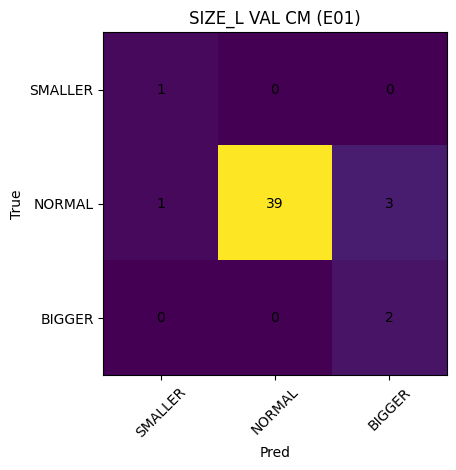

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_L_gtmask.pt | best: 0.72977158343012


SIZE_L train E02: 100%|██████████| 116/116 [14:42<00:00,  7.61s/it]
                                                                 

[SIZE_L][E02] tr_loss=0.5212 va_loss=0.2685 val_f1m=0.8254 | perF1=['0.500', '0.976', '1.000']


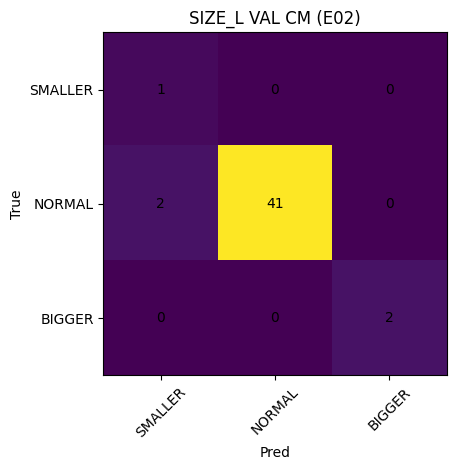

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_L_gtmask.pt | best: 0.8253968253968255


SIZE_L train E03: 100%|██████████| 116/116 [14:33<00:00,  7.53s/it]
                                                                 

[SIZE_L][E03] tr_loss=0.3037 va_loss=0.1895 val_f1m=0.7546 | perF1=['0.500', '0.964', '0.800']


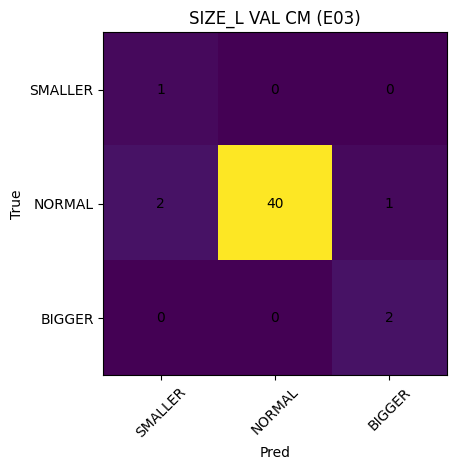

EarlyStop: no improve 1/7 | best=0.8253968253968255


SIZE_L train E04: 100%|██████████| 116/116 [14:24<00:00,  7.45s/it]
                                                                 

[SIZE_L][E04] tr_loss=0.1500 va_loss=0.1406 val_f1m=0.7700 | perF1=['0.667', '0.977', '0.667']


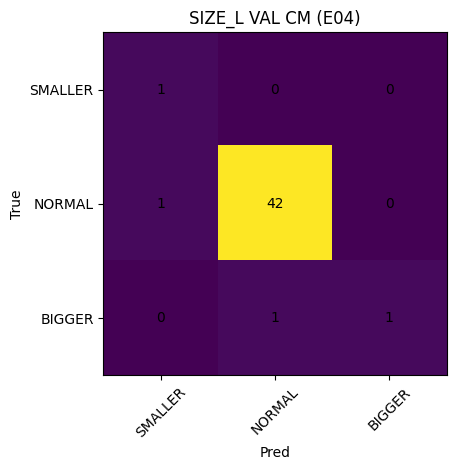

EarlyStop: no improve 2/7 | best=0.8253968253968255


SIZE_L train E05: 100%|██████████| 116/116 [14:51<00:00,  7.69s/it]
                                                                 

[SIZE_L][E05] tr_loss=0.0952 va_loss=1.0062 val_f1m=0.5126 | perF1=['0.200', '0.838', '0.500']


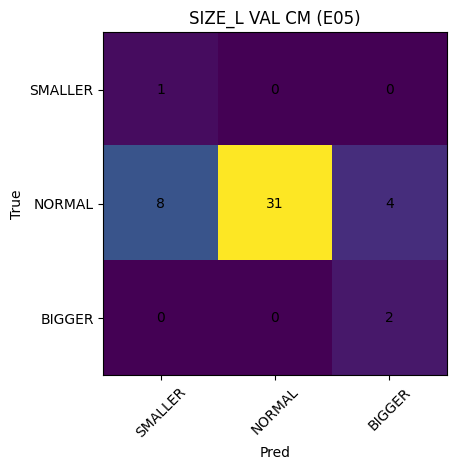

EarlyStop: no improve 3/7 | best=0.8253968253968255


SIZE_L train E06: 100%|██████████| 116/116 [14:53<00:00,  7.70s/it]
                                                                 

[SIZE_L][E06] tr_loss=0.1953 va_loss=0.2579 val_f1m=0.7060 | perF1=['0.500', '0.951', '0.667']


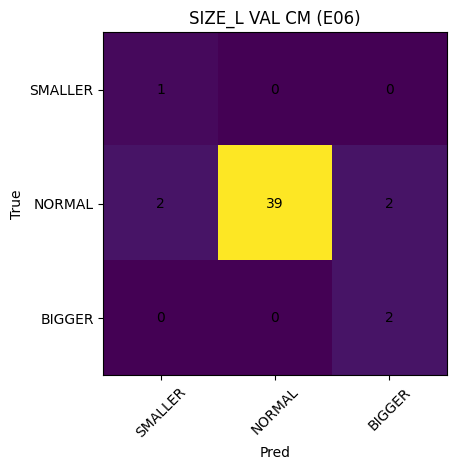

EarlyStop: no improve 4/7 | best=0.8253968253968255


SIZE_L train E07: 100%|██████████| 116/116 [16:00<00:00,  8.28s/it]
                                                                 

[SIZE_L][E07] tr_loss=0.0881 va_loss=0.3009 val_f1m=0.7880 | perF1=['0.400', '0.964', '1.000']


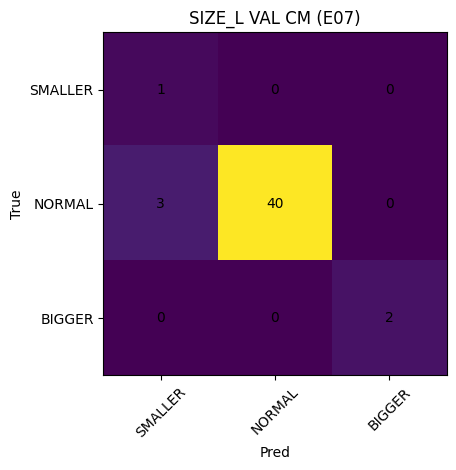

EarlyStop: no improve 5/7 | best=0.8253968253968255


SIZE_L train E08: 100%|██████████| 116/116 [16:30<00:00,  8.54s/it]
                                                                 

[SIZE_L][E08] tr_loss=0.1127 va_loss=0.1187 val_f1m=0.8810 | perF1=['1.000', '0.976', '0.667']


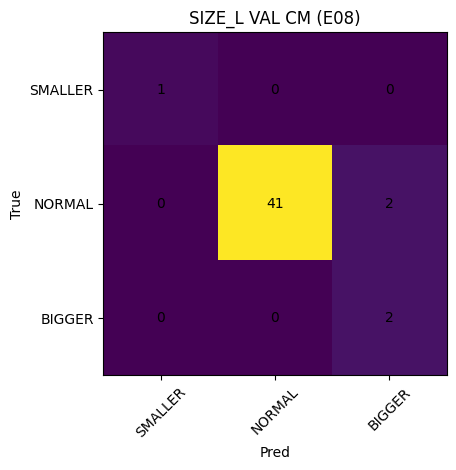

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_L_gtmask.pt | best: 0.8809523809523809


SIZE_L train E09: 100%|██████████| 116/116 [15:48<00:00,  8.18s/it]
                                                                 

[SIZE_L][E09] tr_loss=0.0170 va_loss=0.0269 val_f1m=1.0000 | perF1=['1.000', '1.000', '1.000']


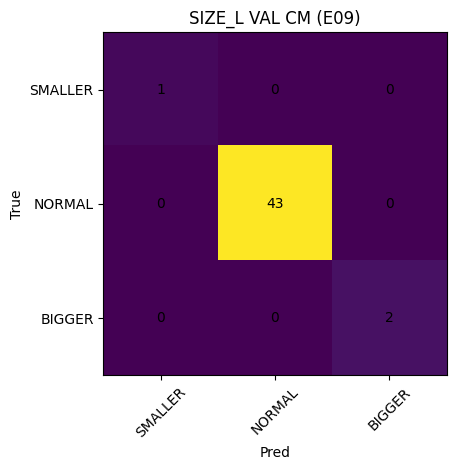

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_L_gtmask.pt | best: 1.0


SIZE_L train E10: 100%|██████████| 116/116 [15:43<00:00,  8.13s/it]
                                                                 

[SIZE_L][E10] tr_loss=0.0006 va_loss=0.0445 val_f1m=0.8850 | perF1=['0.667', '0.988', '1.000']


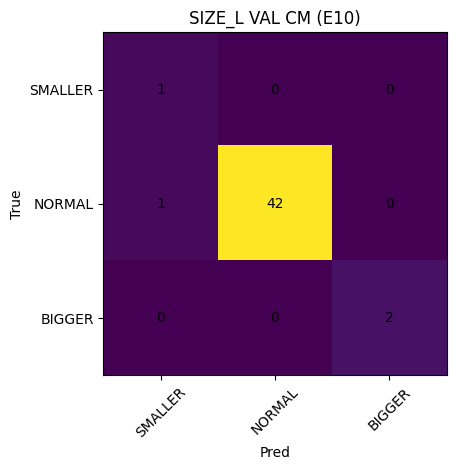

EarlyStop: no improve 1/7 | best=1.0


SIZE_L train E11: 100%|██████████| 116/116 [15:15<00:00,  7.89s/it]
                                                                 

[SIZE_L][E11] tr_loss=0.0002 va_loss=0.0572 val_f1m=0.8850 | perF1=['0.667', '0.988', '1.000']


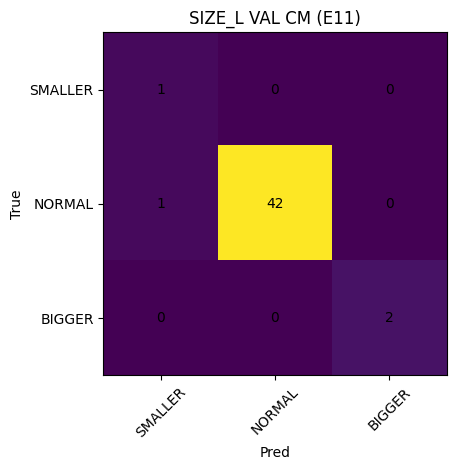

EarlyStop: no improve 2/7 | best=1.0


SIZE_L train E12: 100%|██████████| 116/116 [15:54<00:00,  8.23s/it]
                                                                 

[SIZE_L][E12] tr_loss=0.0001 va_loss=0.0828 val_f1m=0.8143 | perF1=['0.667', '0.976', '0.800']


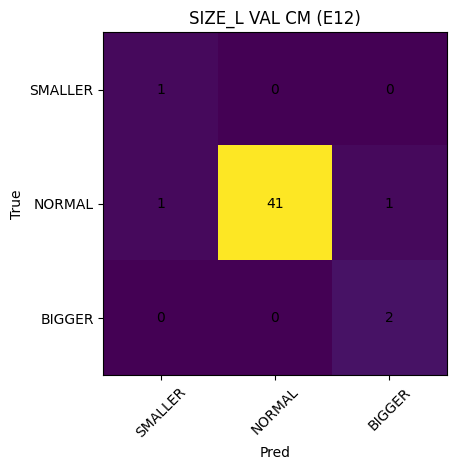

EarlyStop: no improve 3/7 | best=1.0


SIZE_L train E13: 100%|██████████| 116/116 [15:35<00:00,  8.07s/it]
                                                                 

[SIZE_L][E13] tr_loss=0.0001 va_loss=0.1073 val_f1m=0.8143 | perF1=['0.667', '0.976', '0.800']


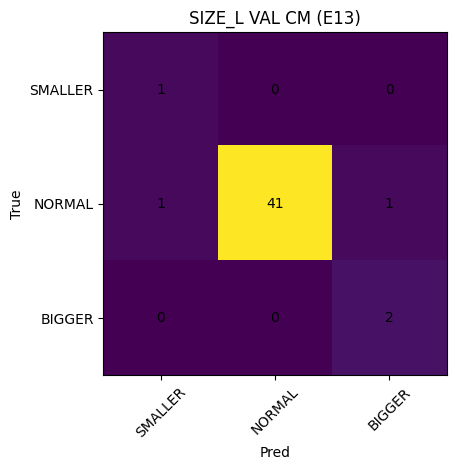

EarlyStop: no improve 4/7 | best=1.0


SIZE_L train E14: 100%|██████████| 116/116 [15:52<00:00,  8.21s/it]
                                                                 

[SIZE_L][E14] tr_loss=0.0001 va_loss=0.1254 val_f1m=0.8143 | perF1=['0.667', '0.976', '0.800']


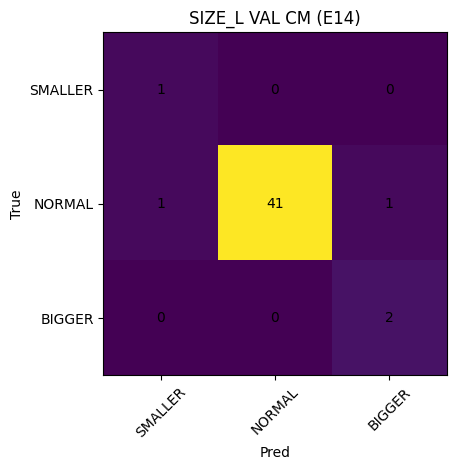

EarlyStop: no improve 5/7 | best=1.0


SIZE_L train E15: 100%|██████████| 116/116 [15:56<00:00,  8.25s/it]
                                                                 

[SIZE_L][E15] tr_loss=0.0001 va_loss=0.1391 val_f1m=0.8143 | perF1=['0.667', '0.976', '0.800']


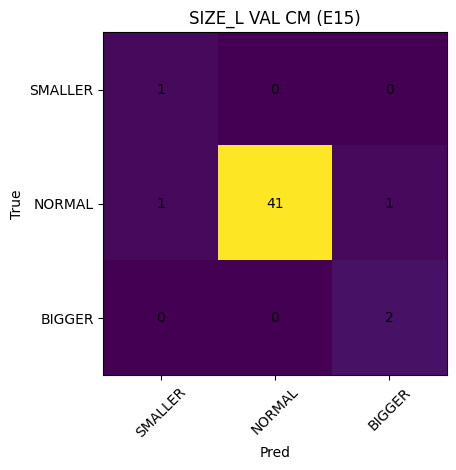

EarlyStop: no improve 6/7 | best=1.0


SIZE_L train E16: 100%|██████████| 116/116 [15:39<00:00,  8.10s/it]
                                                                 

[SIZE_L][E16] tr_loss=0.0000 va_loss=0.1471 val_f1m=0.8143 | perF1=['0.667', '0.976', '0.800']


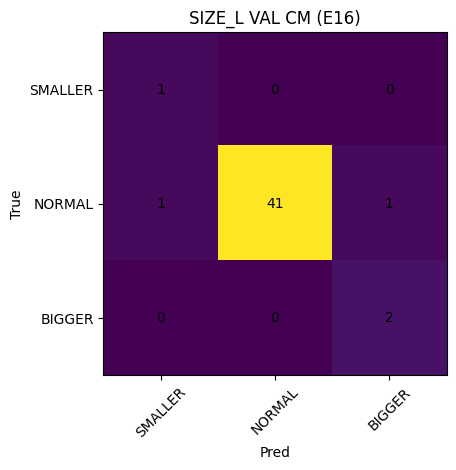

EarlyStop: no improve 7/7 | best=1.0
STOP Early stop triggered.

OK Reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_L_gtmask.pt | epoch: 9 | best: 1.0


SIZE_L TEST (full): 100%|██████████| 10/10 [00:15<00:00,  1.52s/it]


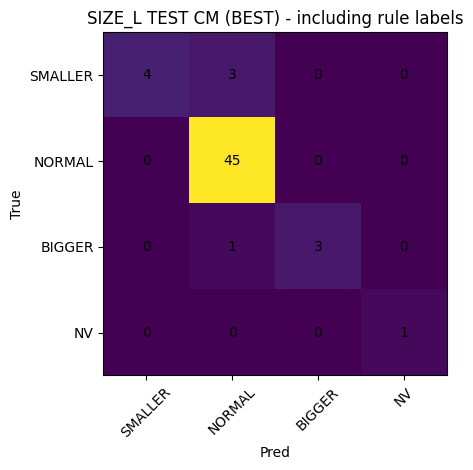

[SIZE_L] TEST macro F1=0.8855 | perF1=['0.727', '0.957', '0.857', '1.000']


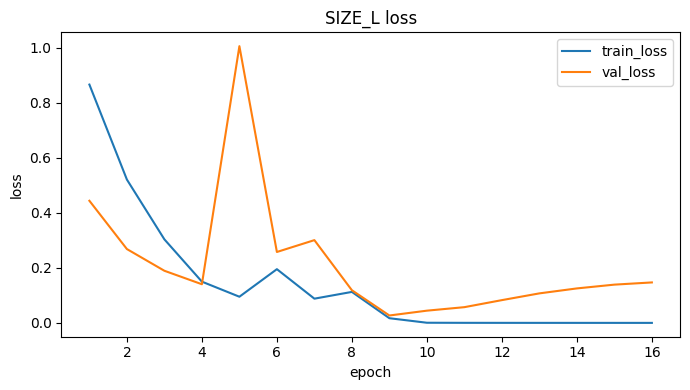

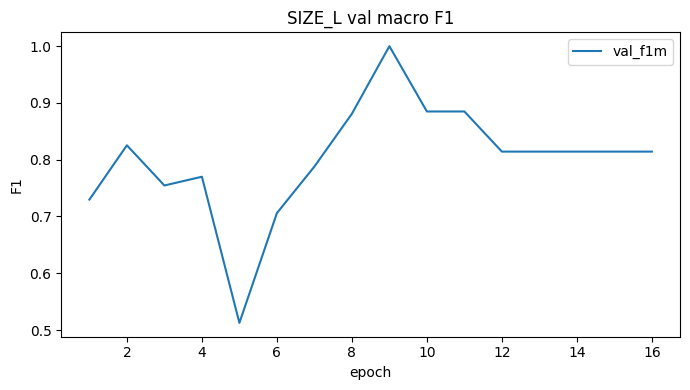


TRAIN HEAD: SIZE_R | classes: ['SMALLER', 'NORMAL', 'BIGGER'] | view weights: [0.75, 0.125, 0.125]


SIZE_R train E01: 100%|██████████| 117/117 [16:36<00:00,  8.52s/it]
                                                                 

[SIZE_R][E01] tr_loss=0.9925 va_loss=0.6157 val_f1m=0.6694 | perF1=['0.571', '0.937', '0.500']


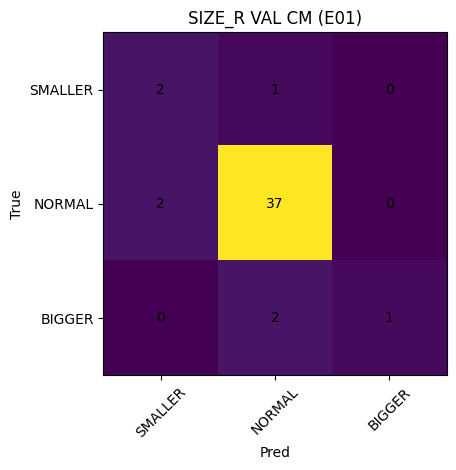

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_R_gtmask.pt | best: 0.6693791440626883


SIZE_R train E02: 100%|██████████| 117/117 [21:05<00:00, 10.82s/it]
                                                                 

[SIZE_R][E02] tr_loss=0.8945 va_loss=0.5897 val_f1m=0.4988 | perF1=['0.000', '0.925', '0.571']


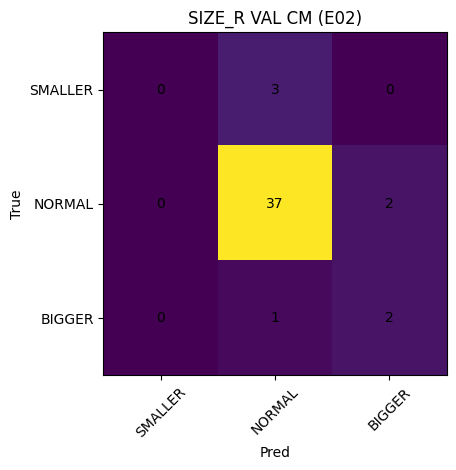

EarlyStop: no improve 1/7 | best=0.6693791440626883


SIZE_R train E03: 100%|██████████| 117/117 [21:10<00:00, 10.86s/it]
                                                                 

[SIZE_R][E03] tr_loss=0.8278 va_loss=0.6611 val_f1m=0.5577 | perF1=['0.000', '0.923', '0.750']


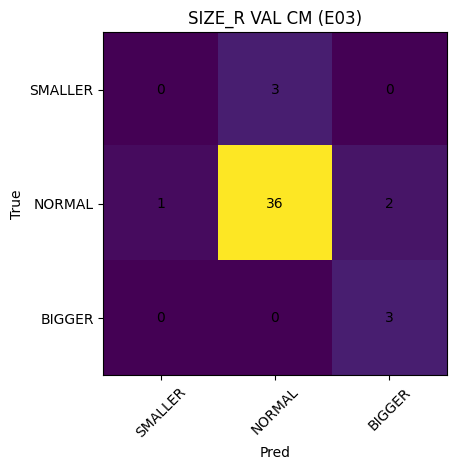

EarlyStop: no improve 2/7 | best=0.6693791440626883


SIZE_R train E04: 100%|██████████| 117/117 [22:49<00:00, 11.70s/it]
                                                                 

[SIZE_R][E04] tr_loss=0.7790 va_loss=0.8377 val_f1m=0.5584 | perF1=['0.333', '0.742', '0.600']


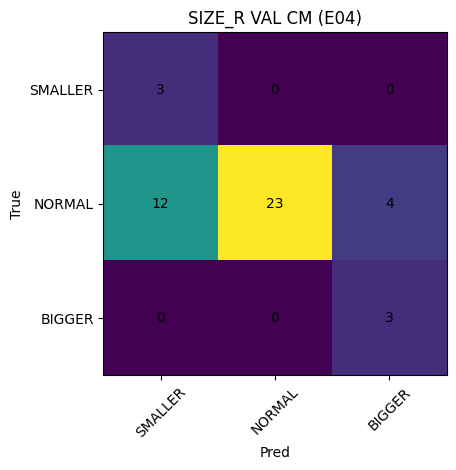

EarlyStop: no improve 3/7 | best=0.6693791440626883


SIZE_R train E05: 100%|██████████| 117/117 [25:32<00:00, 13.10s/it]
                                                                 

[SIZE_R][E05] tr_loss=0.6480 va_loss=0.3801 val_f1m=0.7734 | perF1=['0.800', '0.949', '0.571']


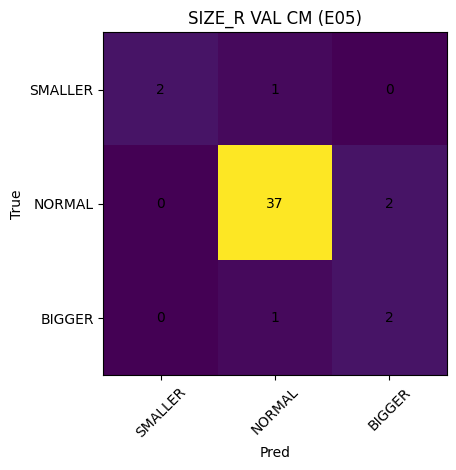

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_R_gtmask.pt | best: 0.7733821733821733


SIZE_R train E06: 100%|██████████| 117/117 [22:23<00:00, 11.49s/it]
                                                                 

[SIZE_R][E06] tr_loss=0.6688 va_loss=0.6011 val_f1m=0.6686 | perF1=['0.571', '0.889', '0.545']


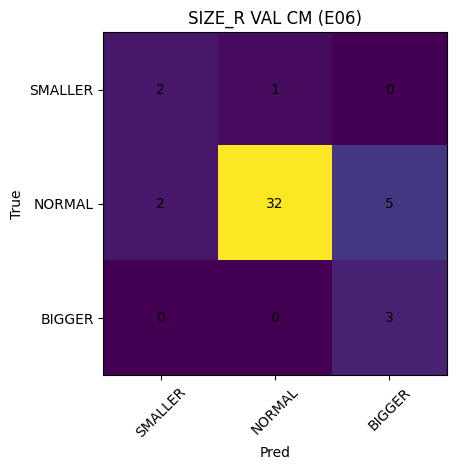

EarlyStop: no improve 1/7 | best=0.7733821733821733


SIZE_R train E07: 100%|██████████| 117/117 [23:53<00:00, 12.25s/it]
                                                                 

[SIZE_R][E07] tr_loss=0.4698 va_loss=0.3821 val_f1m=0.7244 | perF1=['0.667', '0.935', '0.571']


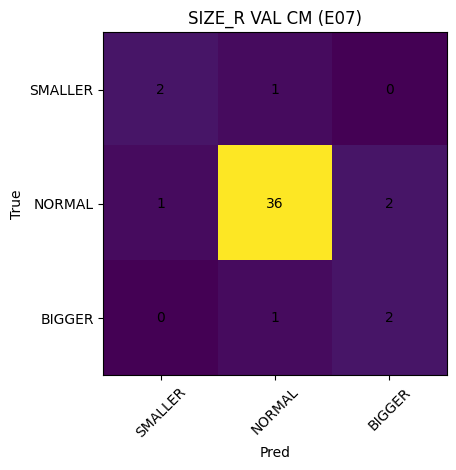

EarlyStop: no improve 2/7 | best=0.7733821733821733


SIZE_R train E08: 100%|██████████| 117/117 [24:13<00:00, 12.43s/it]
                                                                 

[SIZE_R][E08] tr_loss=0.3689 va_loss=0.4426 val_f1m=0.6671 | perF1=['0.667', '0.873', '0.462']


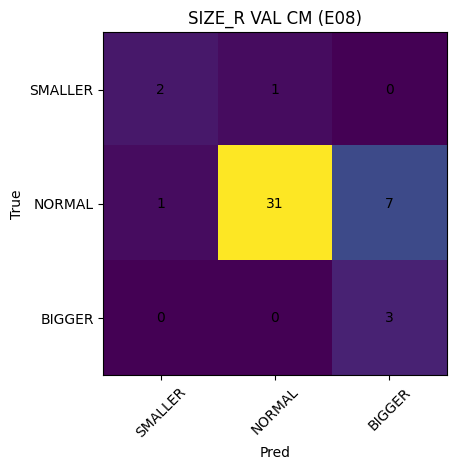

EarlyStop: no improve 3/7 | best=0.7733821733821733


SIZE_R train E09: 100%|██████████| 117/117 [23:45<00:00, 12.18s/it]
                                                                 

[SIZE_R][E09] tr_loss=0.2568 va_loss=1.2900 val_f1m=0.3638 | perF1=['0.000', '0.806', '0.286']


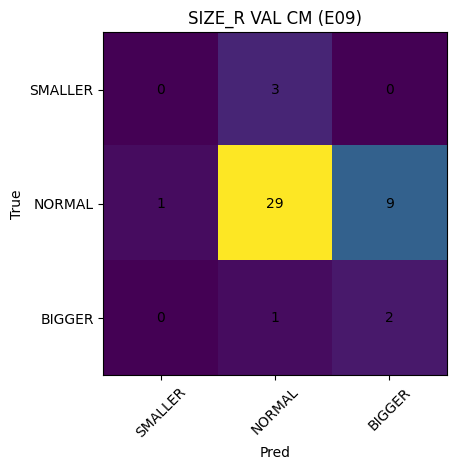

EarlyStop: no improve 4/7 | best=0.7733821733821733


SIZE_R train E10: 100%|██████████| 117/117 [26:04<00:00, 13.37s/it]
                                                                 

[SIZE_R][E10] tr_loss=0.2053 va_loss=0.6635 val_f1m=0.5526 | perF1=['0.333', '0.880', '0.444']


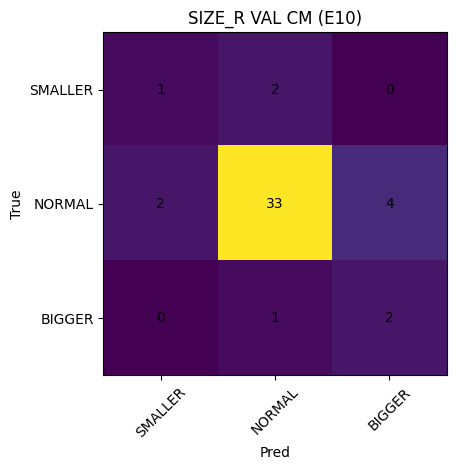

EarlyStop: no improve 5/7 | best=0.7733821733821733


SIZE_R train E11: 100%|██████████| 117/117 [22:59<00:00, 11.79s/it]
                                                                 

[SIZE_R][E11] tr_loss=0.1757 va_loss=0.5964 val_f1m=0.5861 | perF1=['0.333', '0.925', '0.500']


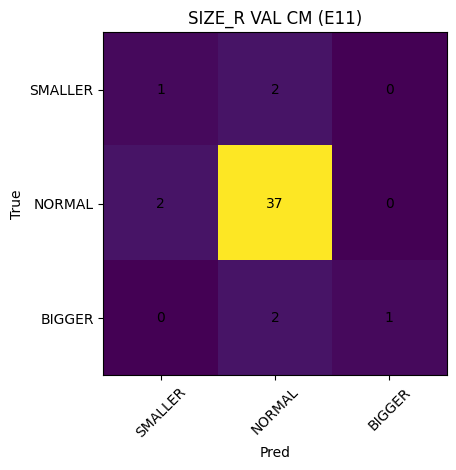

EarlyStop: no improve 6/7 | best=0.7733821733821733


SIZE_R train E12: 100%|██████████| 117/117 [30:50<00:00, 15.81s/it]
                                                                 

[SIZE_R][E12] tr_loss=0.0956 va_loss=0.7596 val_f1m=0.5277 | perF1=['0.400', '0.897', '0.286']


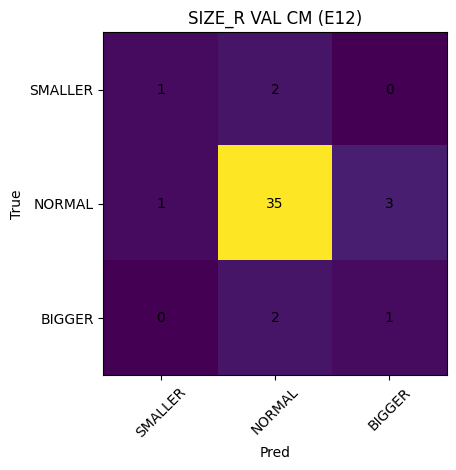

EarlyStop: no improve 7/7 | best=0.7733821733821733
STOP Early stop triggered.

OK Reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_SIZE_R_gtmask.pt | epoch: 5 | best: 0.7733821733821733


SIZE_R TEST (full): 100%|██████████| 10/10 [00:37<00:00,  3.75s/it]


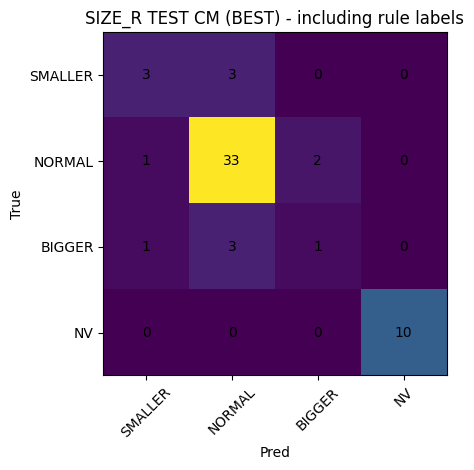

[SIZE_R] TEST macro F1=0.6689 | perF1=['0.545', '0.880', '0.250', '1.000']


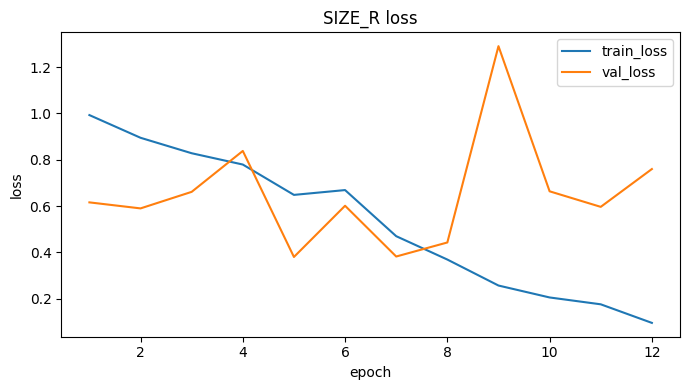

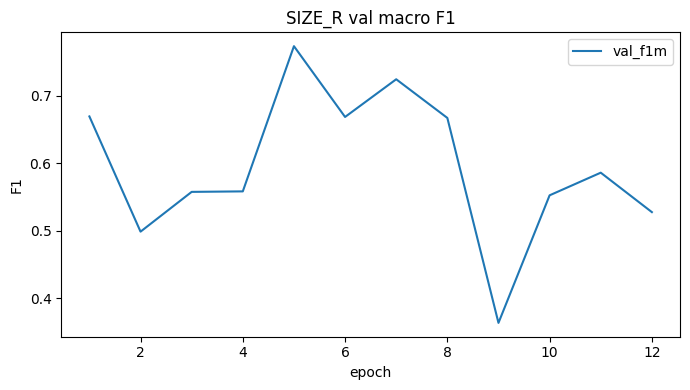


TRAIN HEAD: UP_L | classes: ['NORMAL', 'REDUCED'] | view weights: [0.6000000238418579, 0.25, 0.15000000596046448]


UP_L train E01: 100%|██████████| 92/92 [20:33<00:00, 13.41s/it]
                                                               

[UP_L][E01] tr_loss=0.7048 va_loss=0.5531 val_f1m=0.4333 | perF1=['0.867', '0.000']


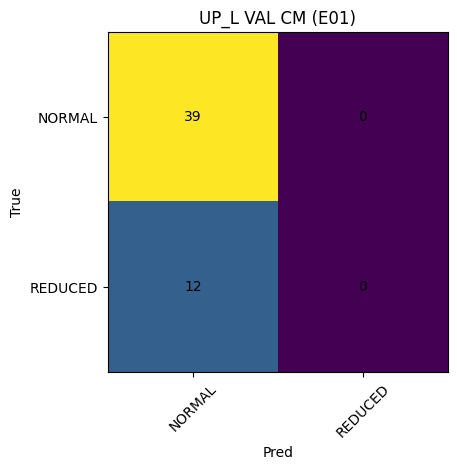

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | best: 0.43333333333333335


UP_L train E02: 100%|██████████| 92/92 [18:04<00:00, 11.78s/it]
                                                               

[UP_L][E02] tr_loss=0.6810 va_loss=0.6726 val_f1m=0.4585 | perF1=['0.703', '0.214']


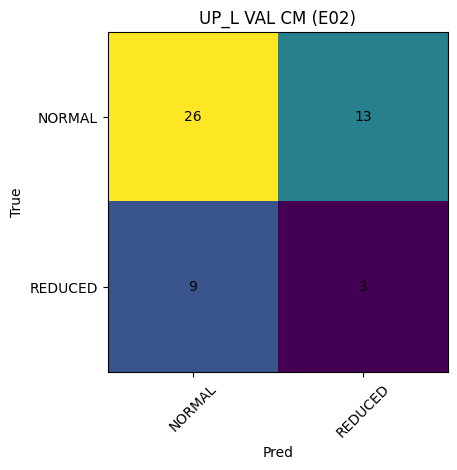

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | best: 0.4584942084942085


UP_L train E03: 100%|██████████| 92/92 [17:57<00:00, 11.72s/it]
                                                               

[UP_L][E03] tr_loss=0.6609 va_loss=0.7178 val_f1m=0.3912 | perF1=['0.415', '0.367']


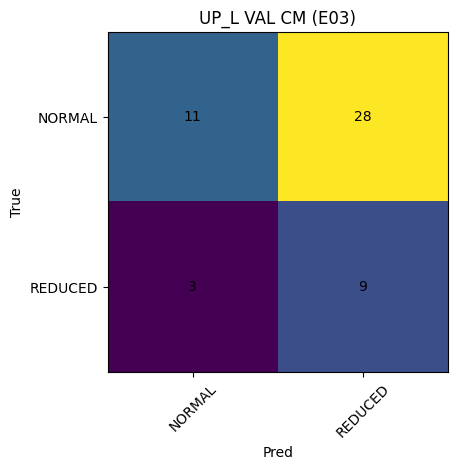

EarlyStop: no improve 1/7 | best=0.4584942084942085


UP_L train E04: 100%|██████████| 92/92 [18:51<00:00, 12.29s/it]
                                                               

[UP_L][E04] tr_loss=0.6668 va_loss=0.6232 val_f1m=0.4811 | perF1=['0.837', '0.125']


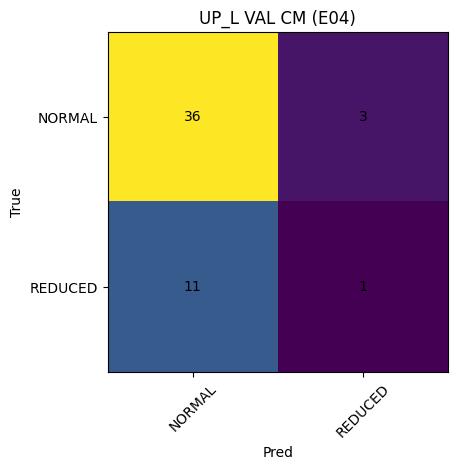

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | best: 0.4811046511627907


UP_L train E05: 100%|██████████| 92/92 [16:48<00:00, 10.96s/it]
                                                               

[UP_L][E05] tr_loss=0.6730 va_loss=0.5848 val_f1m=0.4270 | perF1=['0.854', '0.000']


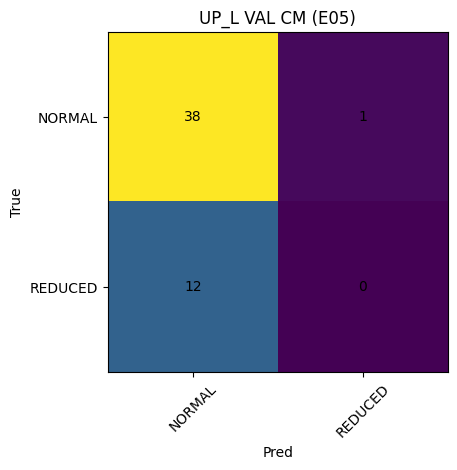

EarlyStop: no improve 1/7 | best=0.4811046511627907


UP_L train E06: 100%|██████████| 92/92 [18:59<00:00, 12.38s/it]
                                                               

[UP_L][E06] tr_loss=0.6677 va_loss=0.5970 val_f1m=0.5032 | perF1=['0.864', '0.143']


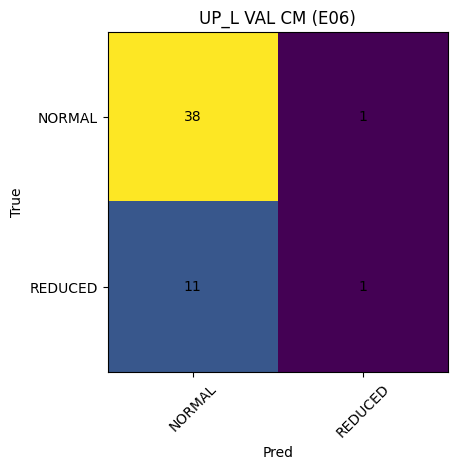

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | best: 0.5032467532467533


UP_L train E07: 100%|██████████| 92/92 [17:09<00:00, 11.19s/it]
                                                               

[UP_L][E07] tr_loss=0.6672 va_loss=0.6117 val_f1m=0.4920 | perF1=['0.851', '0.133']


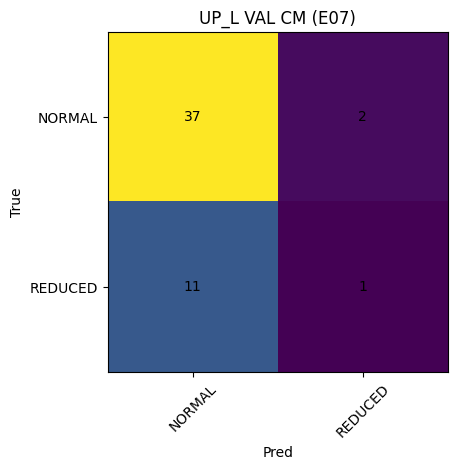

EarlyStop: no improve 1/7 | best=0.5032467532467533


UP_L train E08: 100%|██████████| 92/92 [16:50<00:00, 10.98s/it]
                                                               

[UP_L][E08] tr_loss=0.6626 va_loss=0.6130 val_f1m=0.5032 | perF1=['0.864', '0.143']


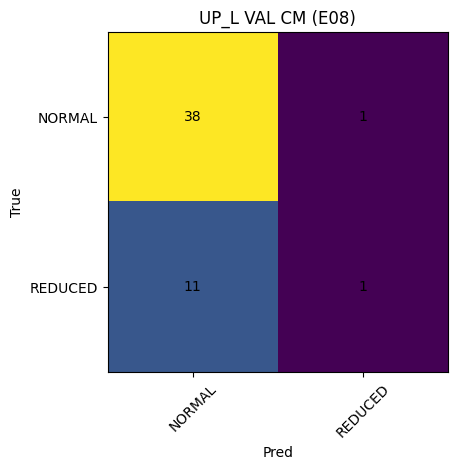

EarlyStop: no improve 2/7 | best=0.5032467532467533


UP_L train E09: 100%|██████████| 92/92 [15:18<00:00,  9.99s/it]
                                                               

[UP_L][E09] tr_loss=0.6534 va_loss=0.6022 val_f1m=0.5032 | perF1=['0.864', '0.143']


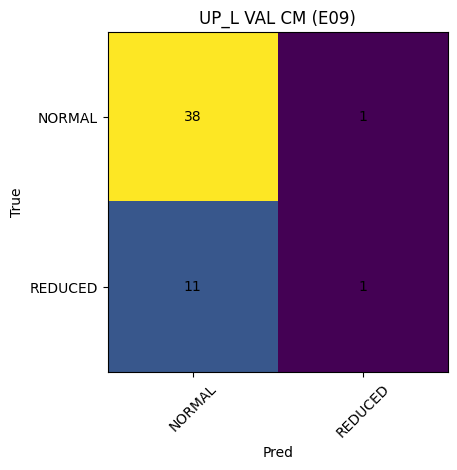

EarlyStop: no improve 3/7 | best=0.5032467532467533


UP_L train E10: 100%|██████████| 92/92 [16:19<00:00, 10.65s/it]
                                                               

[UP_L][E10] tr_loss=0.6554 va_loss=0.6864 val_f1m=0.4333 | perF1=['0.533', '0.333']


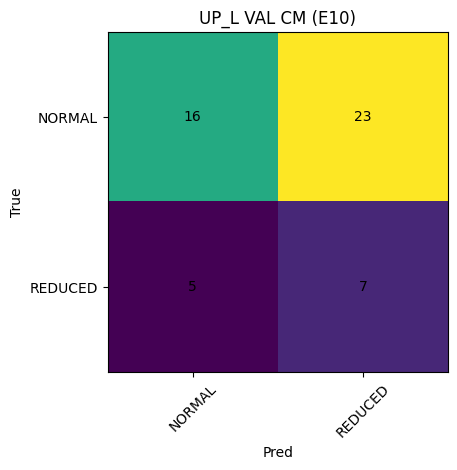

EarlyStop: no improve 4/7 | best=0.5032467532467533


UP_L train E11: 100%|██████████| 92/92 [15:49<00:00, 10.32s/it]
                                                               

[UP_L][E11] tr_loss=0.6628 va_loss=0.6658 val_f1m=0.4838 | perF1=['0.737', '0.231']


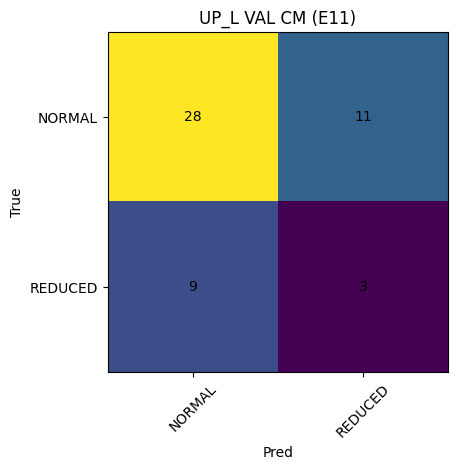

EarlyStop: no improve 5/7 | best=0.5032467532467533


UP_L train E12: 100%|██████████| 92/92 [19:12<00:00, 12.52s/it]
                                                               

[UP_L][E12] tr_loss=0.6574 va_loss=0.6447 val_f1m=0.5796 | perF1=['0.843', '0.316']


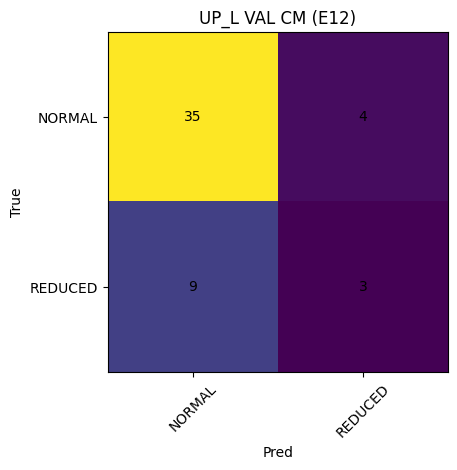

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | best: 0.579581483830057


UP_L train E13: 100%|██████████| 92/92 [19:01<00:00, 12.41s/it]
                                                               

[UP_L][E13] tr_loss=0.6615 va_loss=0.5917 val_f1m=0.5032 | perF1=['0.864', '0.143']


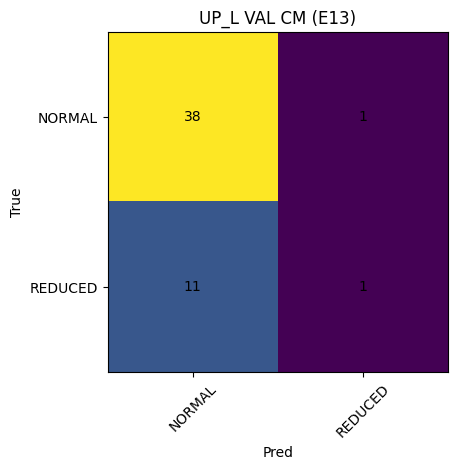

EarlyStop: no improve 1/7 | best=0.579581483830057


UP_L train E14: 100%|██████████| 92/92 [20:32<00:00, 13.40s/it]
                                                               

[UP_L][E14] tr_loss=0.6640 va_loss=0.5965 val_f1m=0.5552 | perF1=['0.860', '0.250']


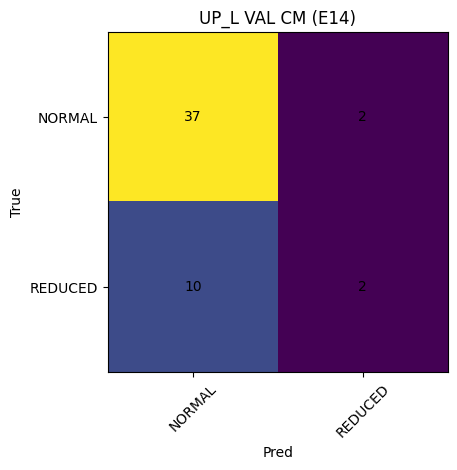

EarlyStop: no improve 2/7 | best=0.579581483830057


UP_L train E15: 100%|██████████| 92/92 [15:45<00:00, 10.28s/it]
                                                               

[UP_L][E15] tr_loss=0.6567 va_loss=0.6008 val_f1m=0.5701 | perF1=['0.874', '0.267']


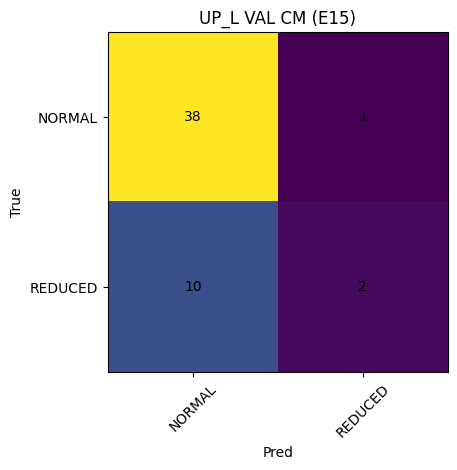

EarlyStop: no improve 3/7 | best=0.579581483830057


UP_L train E16: 100%|██████████| 92/92 [17:08<00:00, 11.18s/it]
                                                               

[UP_L][E16] tr_loss=0.6579 va_loss=0.5745 val_f1m=0.5032 | perF1=['0.864', '0.143']


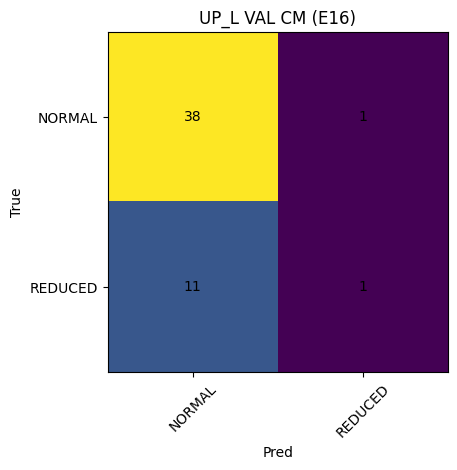

EarlyStop: no improve 4/7 | best=0.579581483830057


UP_L train E17: 100%|██████████| 92/92 [15:56<00:00, 10.39s/it]
                                                               

[UP_L][E17] tr_loss=0.6673 va_loss=0.5797 val_f1m=0.5032 | perF1=['0.864', '0.143']


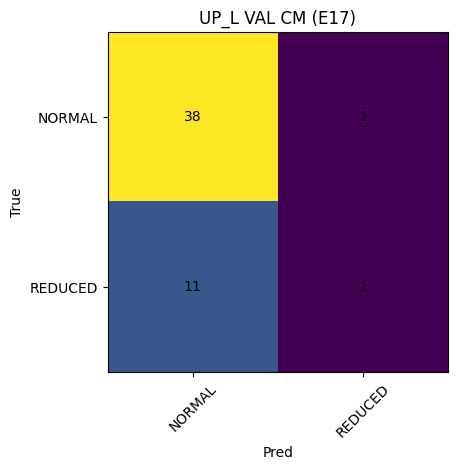

EarlyStop: no improve 5/7 | best=0.579581483830057


UP_L train E18: 100%|██████████| 92/92 [17:17<00:00, 11.28s/it]
                                                               

[UP_L][E18] tr_loss=0.6521 va_loss=0.5873 val_f1m=0.5032 | perF1=['0.864', '0.143']


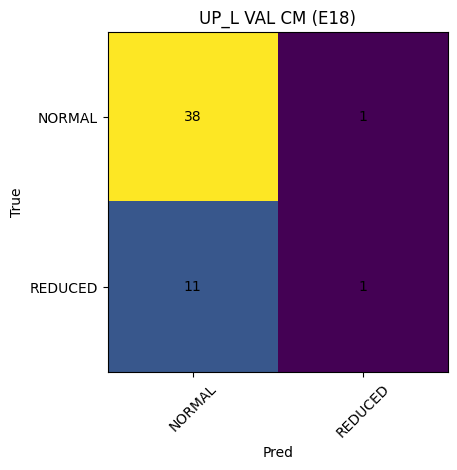

EarlyStop: no improve 6/7 | best=0.579581483830057


UP_L train E19: 100%|██████████| 92/92 [17:58<00:00, 11.73s/it]
                                                               

[UP_L][E19] tr_loss=0.6491 va_loss=0.6073 val_f1m=0.5552 | perF1=['0.860', '0.250']


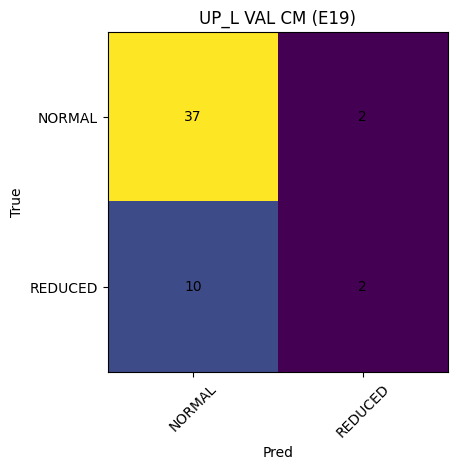

EarlyStop: no improve 7/7 | best=0.579581483830057
STOP Early stop triggered.

OK Reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_L_gtmask.pt | epoch: 12 | best: 0.579581483830057


UP_L TEST (full): 100%|██████████| 10/10 [00:34<00:00,  3.46s/it]


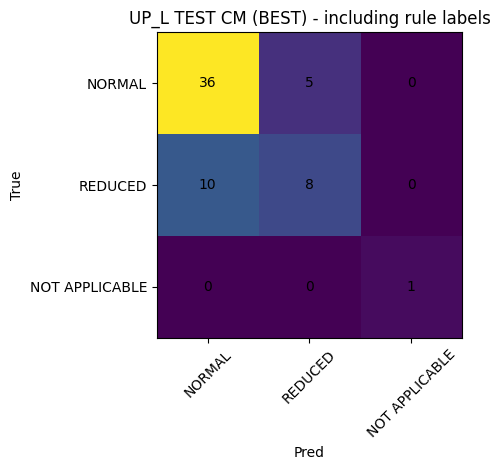

[UP_L] TEST macro F1=0.7812 | perF1=['0.828', '0.516', '1.000']


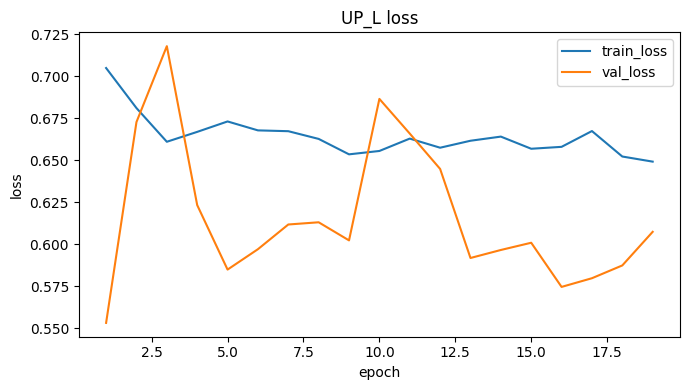

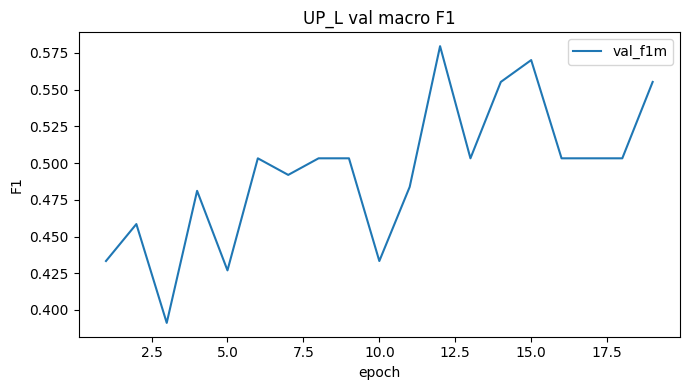


TRAIN HEAD: UP_R | classes: ['NORMAL', 'REDUCED'] | view weights: [0.6000000238418579, 0.15000000596046448, 0.25]


UP_R train E01: 100%|██████████| 95/95 [20:16<00:00, 12.81s/it]
                                                               

[UP_R][E01] tr_loss=0.7045 va_loss=0.5883 val_f1m=0.8162 | perF1=['0.882', '0.750']


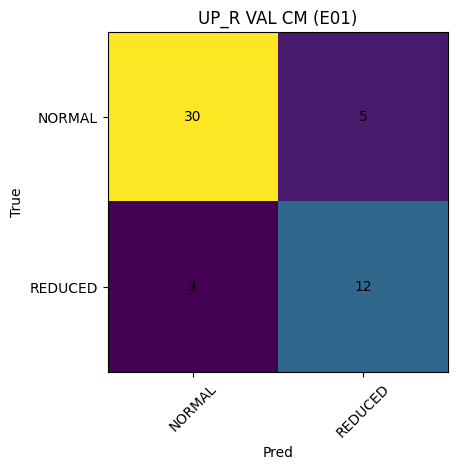

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | best: 0.8161764705882353


UP_R train E02: 100%|██████████| 95/95 [11:32<00:00,  7.28s/it]
                                                               

[UP_R][E02] tr_loss=0.6507 va_loss=0.5312 val_f1m=0.5935 | perF1=['0.854', '0.333']


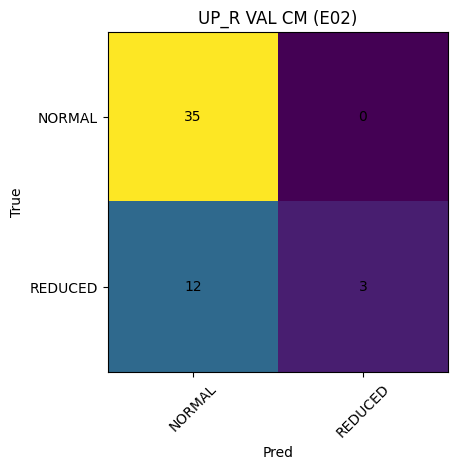

EarlyStop: no improve 1/7 | best=0.8161764705882353


UP_R train E03: 100%|██████████| 95/95 [11:31<00:00,  7.28s/it]
                                                               

[UP_R][E03] tr_loss=0.6409 va_loss=0.4746 val_f1m=0.8355 | perF1=['0.921', '0.750']


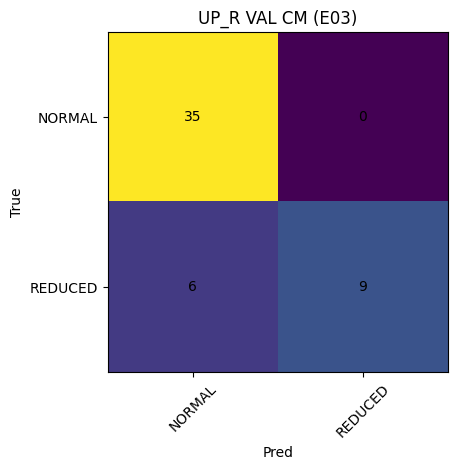

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | best: 0.8355263157894737


UP_R train E04: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E04] tr_loss=0.5677 va_loss=0.5587 val_f1m=0.7396 | perF1=['0.812', '0.667']


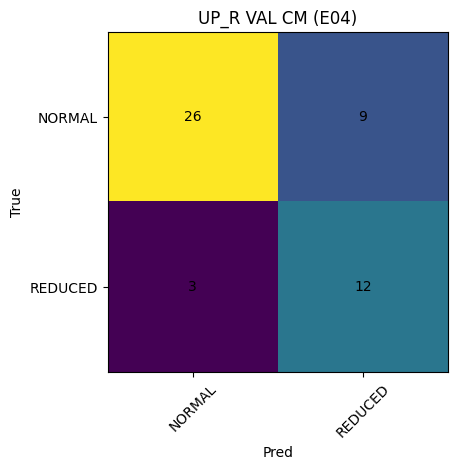

EarlyStop: no improve 1/7 | best=0.8355263157894737


UP_R train E05: 100%|██████████| 95/95 [11:29<00:00,  7.26s/it]
                                                               

[UP_R][E05] tr_loss=0.5563 va_loss=0.5929 val_f1m=0.7640 | perF1=['0.825', '0.703']


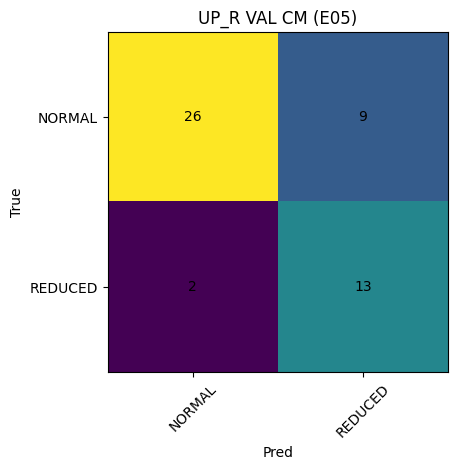

EarlyStop: no improve 2/7 | best=0.8355263157894737


UP_R train E06: 100%|██████████| 95/95 [11:31<00:00,  7.28s/it]
                                                               

[UP_R][E06] tr_loss=0.4621 va_loss=0.3310 val_f1m=0.8355 | perF1=['0.921', '0.750']


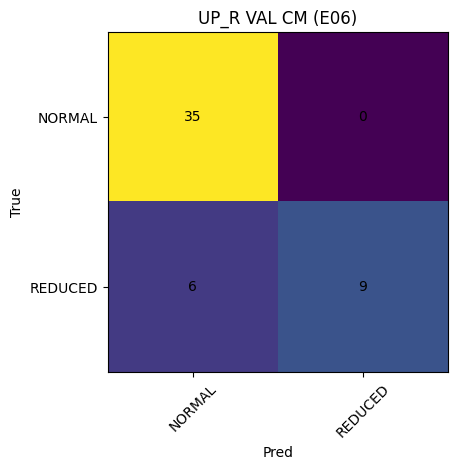

EarlyStop: no improve 3/7 | best=0.8355263157894737


UP_R train E07: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E07] tr_loss=0.4252 va_loss=0.3275 val_f1m=0.8024 | perF1=['0.909', '0.696']


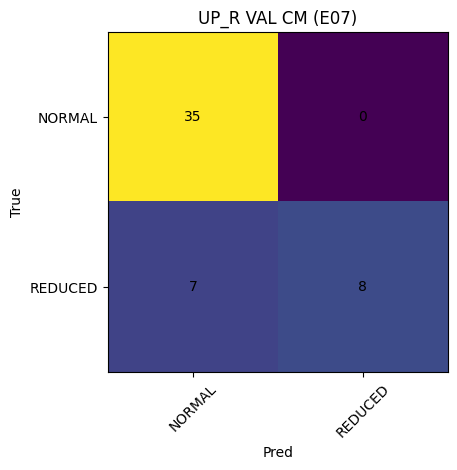

EarlyStop: no improve 4/7 | best=0.8355263157894737


UP_R train E08: 100%|██████████| 95/95 [11:28<00:00,  7.25s/it]
                                                               

[UP_R][E08] tr_loss=0.3879 va_loss=0.3149 val_f1m=0.8571 | perF1=['0.914', '0.800']


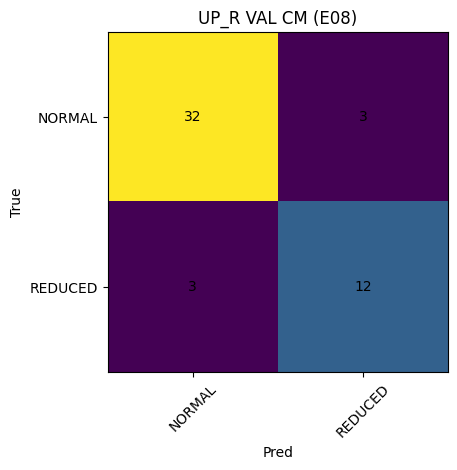

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | best: 0.8571428571428572


UP_R train E09: 100%|██████████| 95/95 [11:28<00:00,  7.25s/it]
                                                               

[UP_R][E09] tr_loss=0.3353 va_loss=0.3894 val_f1m=0.8417 | perF1=['0.896', '0.788']


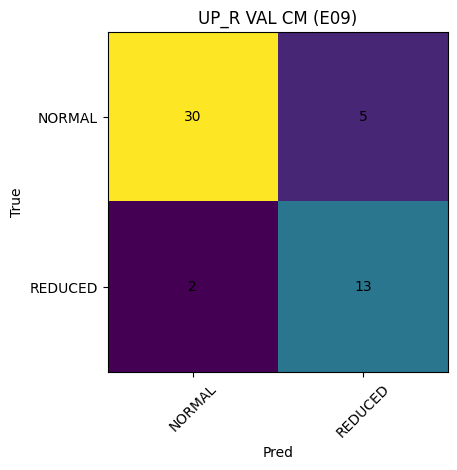

EarlyStop: no improve 1/7 | best=0.8571428571428572


UP_R train E10: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E10] tr_loss=0.2729 va_loss=0.3869 val_f1m=0.7965 | perF1=['0.866', '0.727']


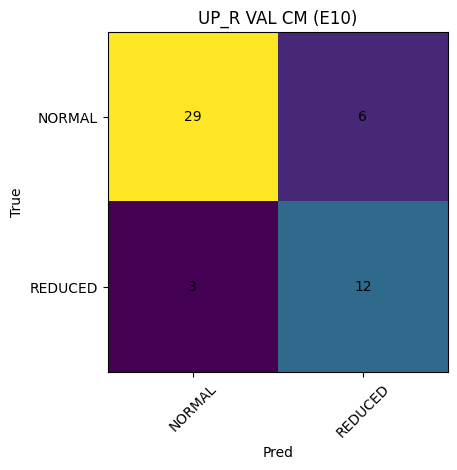

EarlyStop: no improve 2/7 | best=0.8571428571428572


UP_R train E11: 100%|██████████| 95/95 [11:32<00:00,  7.29s/it]
                                                               

[UP_R][E11] tr_loss=0.2218 va_loss=0.6996 val_f1m=0.7453 | perF1=['0.806', '0.684']


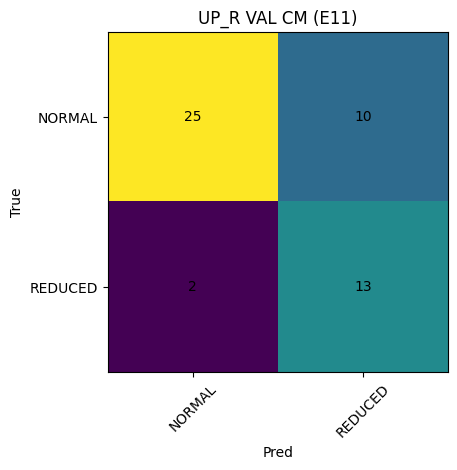

EarlyStop: no improve 3/7 | best=0.8571428571428572


UP_R train E12: 100%|██████████| 95/95 [11:29<00:00,  7.26s/it]
                                                               

[UP_R][E12] tr_loss=0.3046 va_loss=0.2761 val_f1m=0.9008 | perF1=['0.944', '0.857']


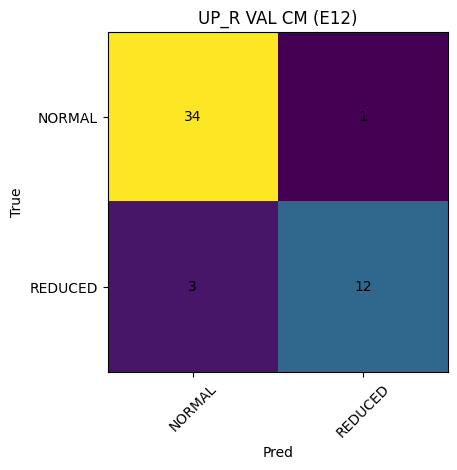

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | best: 0.9007936507936507


UP_R train E13: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E13] tr_loss=0.1441 va_loss=0.2312 val_f1m=0.9271 | perF1=['0.958', '0.897']


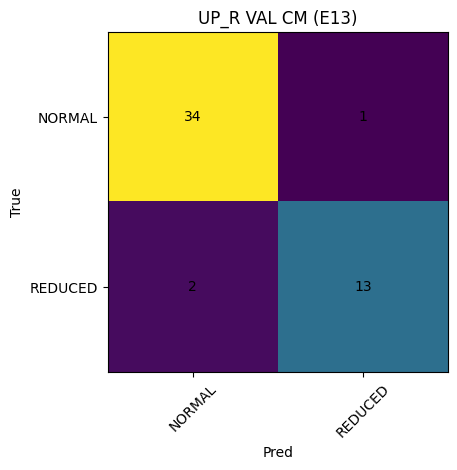

OK Saved best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | best: 0.9271491015055853


UP_R train E14: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E14] tr_loss=0.1178 va_loss=0.3644 val_f1m=0.8786 | perF1=['0.930', '0.828']


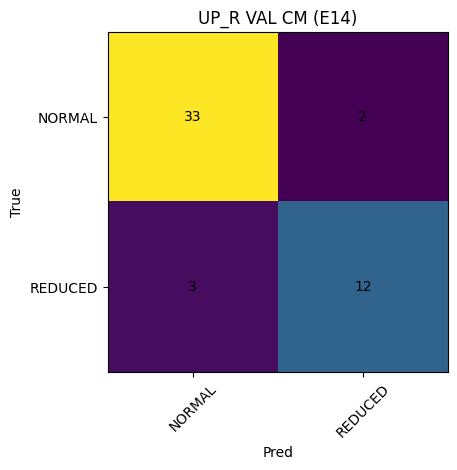

EarlyStop: no improve 1/7 | best=0.9271491015055853


UP_R train E15: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E15] tr_loss=0.2550 va_loss=0.3915 val_f1m=0.8024 | perF1=['0.909', '0.696']


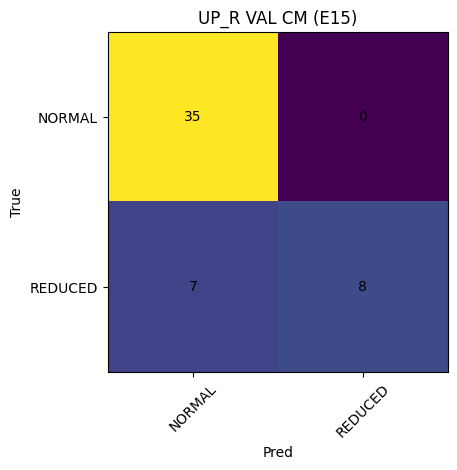

EarlyStop: no improve 2/7 | best=0.9271491015055853


UP_R train E16: 100%|██████████| 95/95 [11:29<00:00,  7.26s/it]
                                                               

[UP_R][E16] tr_loss=0.3463 va_loss=0.3100 val_f1m=0.8732 | perF1=['0.932', '0.815']


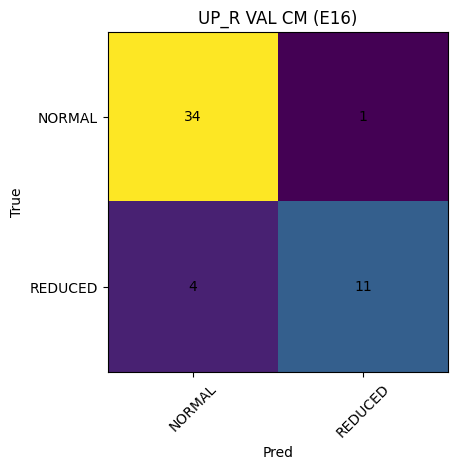

EarlyStop: no improve 3/7 | best=0.9271491015055853


UP_R train E17: 100%|██████████| 95/95 [11:32<00:00,  7.29s/it]
                                                               

[UP_R][E17] tr_loss=0.2305 va_loss=0.2482 val_f1m=0.9008 | perF1=['0.944', '0.857']


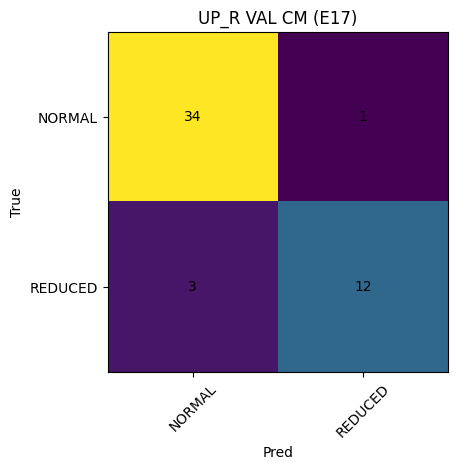

EarlyStop: no improve 4/7 | best=0.9271491015055853


UP_R train E18: 100%|██████████| 95/95 [11:29<00:00,  7.25s/it]
                                                               

[UP_R][E18] tr_loss=0.1238 va_loss=0.3716 val_f1m=0.8133 | perF1=['0.907', '0.720']


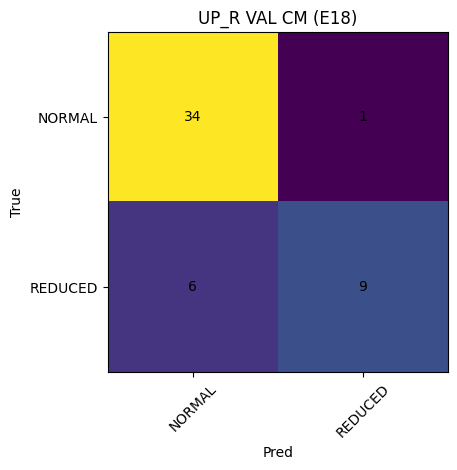

EarlyStop: no improve 5/7 | best=0.9271491015055853


UP_R train E19: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E19] tr_loss=0.0947 va_loss=0.7305 val_f1m=0.7500 | perF1=['0.800', '0.700']


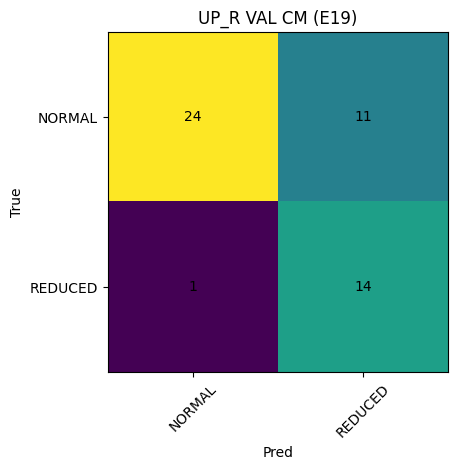

EarlyStop: no improve 6/7 | best=0.9271491015055853


UP_R train E20: 100%|██████████| 95/95 [11:30<00:00,  7.27s/it]
                                                               

[UP_R][E20] tr_loss=0.0987 va_loss=0.5467 val_f1m=0.8217 | perF1=['0.879', '0.765']


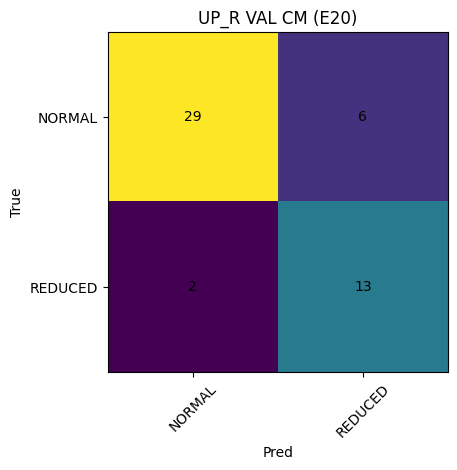

EarlyStop: no improve 7/7 | best=0.9271491015055853
STOP Early stop triggered.

OK Reloaded best: C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\best_UP_R_gtmask.pt | epoch: 13 | best: 0.9271491015055853


UP_R TEST (full): 100%|██████████| 10/10 [00:14<00:00,  1.48s/it]


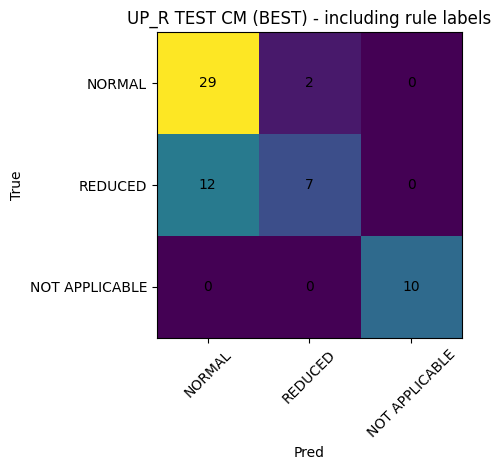

[UP_R] TEST macro F1=0.7685 | perF1=['0.806', '0.500', '1.000']


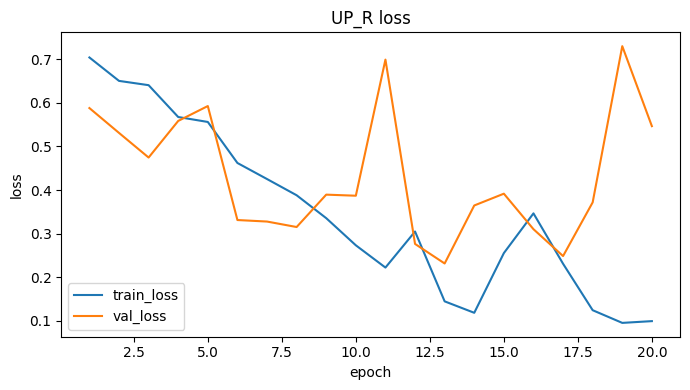

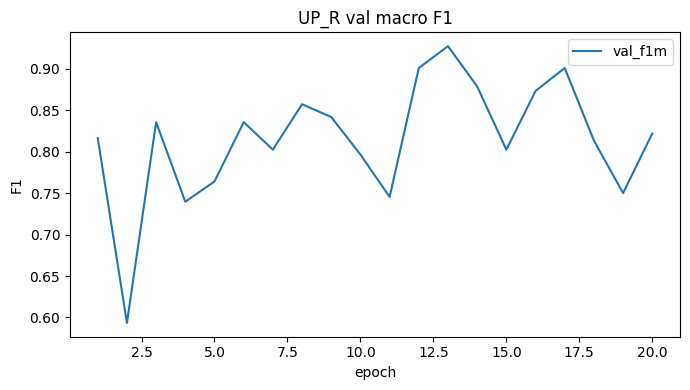

In [15]:
# CELL 24 - TRAIN + EVAL FOR SIZE + UPTAKE HEADS (ConvNeXt-Base 4ch) - WEIGHTED 3-VIEW + EARLY STOP + PROOFS

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import math

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

SIZE3 = ["SMALLER", "NORMAL", "BIGGER"]
SIZE4 = ["SMALLER", "NORMAL", "BIGGER", "NV"]
UP2   = ["NORMAL", "REDUCED"]
UP3   = ["NORMAL", "REDUCED", "NOT APPLICABLE"]

def get_size_label(row, side):
    return norm_str(row[COL_SZ_L if side=="L" else COL_SZ_R])

def get_uptake_label(row, side):
    return norm_str(row[COL_UP_L if side=="L" else COL_UP_R])

def is_po(lab):
    return lab == "PO"

class PatientHeadDataset(Dataset):
    def __init__(self, pids, head_name):
        self.pids = list(pids)
        self.head = head_name

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3,4,IMG_SIZE,IMG_SIZE), dtype=np.float32)
        axL = np.zeros((3,), dtype=np.float32)
        axR = np.zeros((3,), dtype=np.float32)

        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)

            if self.head.startswith("SIZE"):
                X[vi] = build_input4(I, mL, mR, mode="SIZE")
            elif self.head == "UP_L":
                X[vi] = build_input4(I, mL, mR, mode="UP_L")
            elif self.head == "UP_R":
                X[vi] = build_input4(I, mL, mR, mode="UP_R")
            else:
                X[vi] = build_input4(I, mL, mR, mode="GEN")

            axL[vi] = major_axis_len(mL)
            axR[vi] = major_axis_len(mR)

        Lp, Rp = patient_presence(pid)

        # Choose a row for GT label (P preferred)
        ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
        row = df.iloc[int(ri)]

        # Training target + validity
        if self.head == "SIZE_L":
            lab = get_size_label(row, "L")
            if (not Lp) or lab in ("NV","",) or is_po(lab):
                y = -1; valid = 0
            else:
                y = SIZE3.index(lab); valid = 1
        elif self.head == "SIZE_R":
            lab = get_size_label(row, "R")
            if (not Rp) or lab in ("NV","",) or is_po(lab):
                y = -1; valid = 0
            else:
                y = SIZE3.index(lab); valid = 1
        elif self.head == "UP_L":
            lab = get_uptake_label(row, "L")
            if (not Lp) or lab in ("NOT APPLICABLE",""):
                y = -1; valid = 0
            else:
                y = UP2.index(lab); valid = 1
        elif self.head == "UP_R":
            lab = get_uptake_label(row, "R")
            if (not Rp) or lab in ("NOT APPLICABLE",""):
                y = -1; valid = 0
            else:
                y = UP2.index(lab); valid = 1
        else:
            y = -1; valid = 0

        feat = np.array([
            float((W_SIZE * axL).sum()),
            float((W_SIZE * axR).sum()),
            float(math.log((1e-6 + (W_SIZE * axL).sum()) / (1e-6 + (W_SIZE * axR).sum()))),
        ], dtype=np.float32)

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "Lp": torch.tensor(int(Lp), dtype=torch.long),
            "Rp": torch.tensor(int(Rp), dtype=torch.long),
        }

def make_oversampled_train_pids(head_name):
    out = []
    for pid in train_p:
        rows = patient_views(pid)
        ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
        row = df.iloc[int(ri)]
        Lp, Rp = patient_presence(pid)

        if head_name == "SIZE_L":
            lab = get_size_label(row, "L")
            if (not Lp) or lab in ("NV","PO",""): 
                continue
            mult = OVERSAMPLE["SIZE_L"].get(lab, 1)
        elif head_name == "SIZE_R":
            lab = get_size_label(row, "R")
            if (not Rp) or lab in ("NV","PO",""):
                continue
            mult = OVERSAMPLE["SIZE_R"].get(lab, 1)
        elif head_name == "UP_L":
            lab = get_uptake_label(row, "L")
            if (not Lp) or lab in ("NOT APPLICABLE",""):
                continue
            mult = OVERSAMPLE["UP_L"].get(lab, 1)
        elif head_name == "UP_R":
            lab = get_uptake_label(row, "R")
            if (not Rp) or lab in ("NOT APPLICABLE",""):
                continue
            mult = OVERSAMPLE["UP_R"].get(lab, 1)
        else:
            continue

        for _ in range(int(mult)):
            out.append(pid)
    return out

class ConvNeXtHead(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = timm.create_model("convnext_base", pretrained=True, in_chans=4, num_classes=0, global_pool="avg")
        self.fc = nn.Sequential(
            nn.Linear(self.backbone.num_features + 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, x3v, feat, w):
        logits = 0
        for vi in range(3):
            f = self.backbone(x3v[:,vi])
            f = torch.cat([f, feat], dim=1)
            lv = self.fc(f)
            logits = logits + float(w[vi]) * lv
        return logits

def train_head(head_name, n_classes, class_names, w_view, max_epochs=30):
    print("\n" + "="*110)
    print("TRAIN HEAD:", head_name, "| classes:", class_names, "| view weights:", w_view.tolist())
    print("="*110)

    tr_ids = make_oversampled_train_pids(head_name)
    tr_ds = PatientHeadDataset(tr_ids, head_name)
    va_ds = PatientHeadDataset(val_p, head_name)
    te_ds = PatientHeadDataset(test_p, head_name)

    tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    te_dl = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = ConvNeXtHead(n_classes=n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()

    best = None
    bad = 0
    best_path = BASE_DIR / f"best_{head_name}_gtmask.pt"

    hist_tr = []
    hist_va = []
    hist_f1 = []

    for ep in range(1, max_epochs+1):
        model.train()
        tr_loss = 0.0
        tr_n = 0
        for batch in tqdm(tr_dl, desc=f"{head_name} train E{ep:02d}"):
            x = batch["x"].to(DEVICE)
            feat = batch["feat"].to(DEVICE)
            y = batch["y"].to(DEVICE)
            valid = batch["valid"].to(DEVICE)

            m = (valid == 1)
            if int(m.sum()) == 0:
                continue
            x = x[m]; feat = feat[m]; y = y[m]

            opt.zero_grad(set_to_none=True)
            logits = model(x, feat, w_view)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            tr_loss += float(loss.item()) * y.size(0)
            tr_n += y.size(0)

        tr_loss = tr_loss / max(tr_n, 1)

        model.eval()
        va_loss = 0.0
        va_n = 0
        y_true = []
        y_pred = []
        with torch.no_grad():
            for batch in tqdm(va_dl, desc=f"{head_name} val   E{ep:02d}", leave=False):
                x = batch["x"].to(DEVICE)
                feat = batch["feat"].to(DEVICE)
                y = batch["y"].to(DEVICE)
                valid = batch["valid"].to(DEVICE)

                m = (valid == 1)
                if int(m.sum()) == 0:
                    continue
                x = x[m]; feat = feat[m]; y = y[m]

                logits = model(x, feat, w_view)
                loss = loss_fn(logits, y)

                va_loss += float(loss.item()) * y.size(0)
                va_n += y.size(0)

                yp = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()
                yt = y.detach().cpu().numpy().tolist()
                y_true.extend([int(t) for t in yt])
                y_pred.extend([int(p) for p in yp])

        va_loss = va_loss / max(va_n, 1)
        cm = confusion_matrix_np(y_true, y_pred, n_classes)
        f1s, f1m = f1_macro_from_cm(cm)

        hist_tr.append(tr_loss); hist_va.append(va_loss); hist_f1.append(f1m)

        print(f"[{head_name}][E{ep:02d}] tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} val_f1m={f1m:.4f} | perF1={['%.3f'%x for x in f1s]}")
        plot_cm(cm, f"{head_name} VAL CM (E{ep:02d})", class_names)

        score = f1m
        improved = (best is None) or (score > best + MIN_DELTA)
        if improved:
            best = score
            bad = 0
            torch.save({"model": model.state_dict(), "epoch": ep, "best": best}, best_path)
            print("OK Saved best:", best_path, "| best:", best)
        else:
            bad += 1
            print(f"EarlyStop: no improve {bad}/{PATIENCE} | best={best}")
            if EARLY_STOP_ON and bad >= PATIENCE:
                print("STOP Early stop triggered.")
                break

    # TEST including rule labels in metrics
    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck["model"])
    model.eval()
    print("\nOK Reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))

    if head_name in ("SIZE_L","SIZE_R"):
        eval_names = SIZE4
    else:
        eval_names = UP3
    eval_n = len(eval_names)

    y_true_full = []
    y_pred_full = []

    with torch.no_grad():
        for batch in tqdm(te_dl, desc=f"{head_name} TEST (full)"):
            x = batch["x"].to(DEVICE)
            feat = batch["feat"].to(DEVICE)
            Lp = batch["Lp"].cpu().numpy().tolist()
            Rp = batch["Rp"].cpu().numpy().tolist()
            pids = batch["pid"]

            logits = model(x, feat, w_view)
            yp = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()

            for bi, pid in enumerate(pids):
                rows = patient_views(pid)
                ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
                row = df.iloc[int(ri)]

                if head_name == "SIZE_L":
                    gt = norm_str(row[COL_SZ_L])
                    if gt == "PO":
                        continue
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NV") if (Lp[bi] == 0 or gt == "NV") else int(yp[bi])

                elif head_name == "SIZE_R":
                    gt = norm_str(row[COL_SZ_R])
                    if gt == "PO":
                        continue
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NV") if (Rp[bi] == 0 or gt == "NV") else int(yp[bi])

                elif head_name == "UP_L":
                    gt = norm_str(row[COL_UP_L])
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NOT APPLICABLE") if (Lp[bi] == 0 or gt == "NOT APPLICABLE") else int(yp[bi])

                elif head_name == "UP_R":
                    gt = norm_str(row[COL_UP_R])
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NOT APPLICABLE") if (Rp[bi] == 0 or gt == "NOT APPLICABLE") else int(yp[bi])

                else:
                    continue

                y_true_full.append(int(gt_idx))
                y_pred_full.append(int(pred_idx))

    cm = confusion_matrix_np(y_true_full, y_pred_full, eval_n)
    f1s, f1m = f1_macro_from_cm(cm)
    plot_cm(cm, f"{head_name} TEST CM (BEST) - including rule labels", eval_names)
    print(f"[{head_name}] TEST macro F1={f1m:.4f} | perF1={['%.3f'%x for x in f1s]}")

    # Curves
    ep = list(range(1, len(hist_tr)+1))
    plt.figure(figsize=(7,4))
    plt.plot(ep, hist_tr, label="train_loss")
    plt.plot(ep, hist_va, label="val_loss")
    plt.title(f"{head_name} loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(ep, hist_f1, label="val_f1m")
    plt.title(f"{head_name} val macro F1"); plt.xlabel("epoch"); plt.ylabel("F1"); plt.legend(); plt.tight_layout(); plt.show()

# RUN ALL (you can comment any line)
train_head("SIZE_L", n_classes=3, class_names=SIZE3, w_view=W_SIZE, max_epochs=30)
train_head("SIZE_R", n_classes=3, class_names=SIZE3, w_view=W_SIZE, max_epochs=30)
train_head("UP_L",   n_classes=2, class_names=UP2,   w_view=W_UP_L, max_epochs=30)
train_head("UP_R",   n_classes=2, class_names=UP2,   w_view=W_UP_R, max_epochs=30)

Saved: C:\Users\User\Downloads\postseg_gt_only_fast.losses.csv


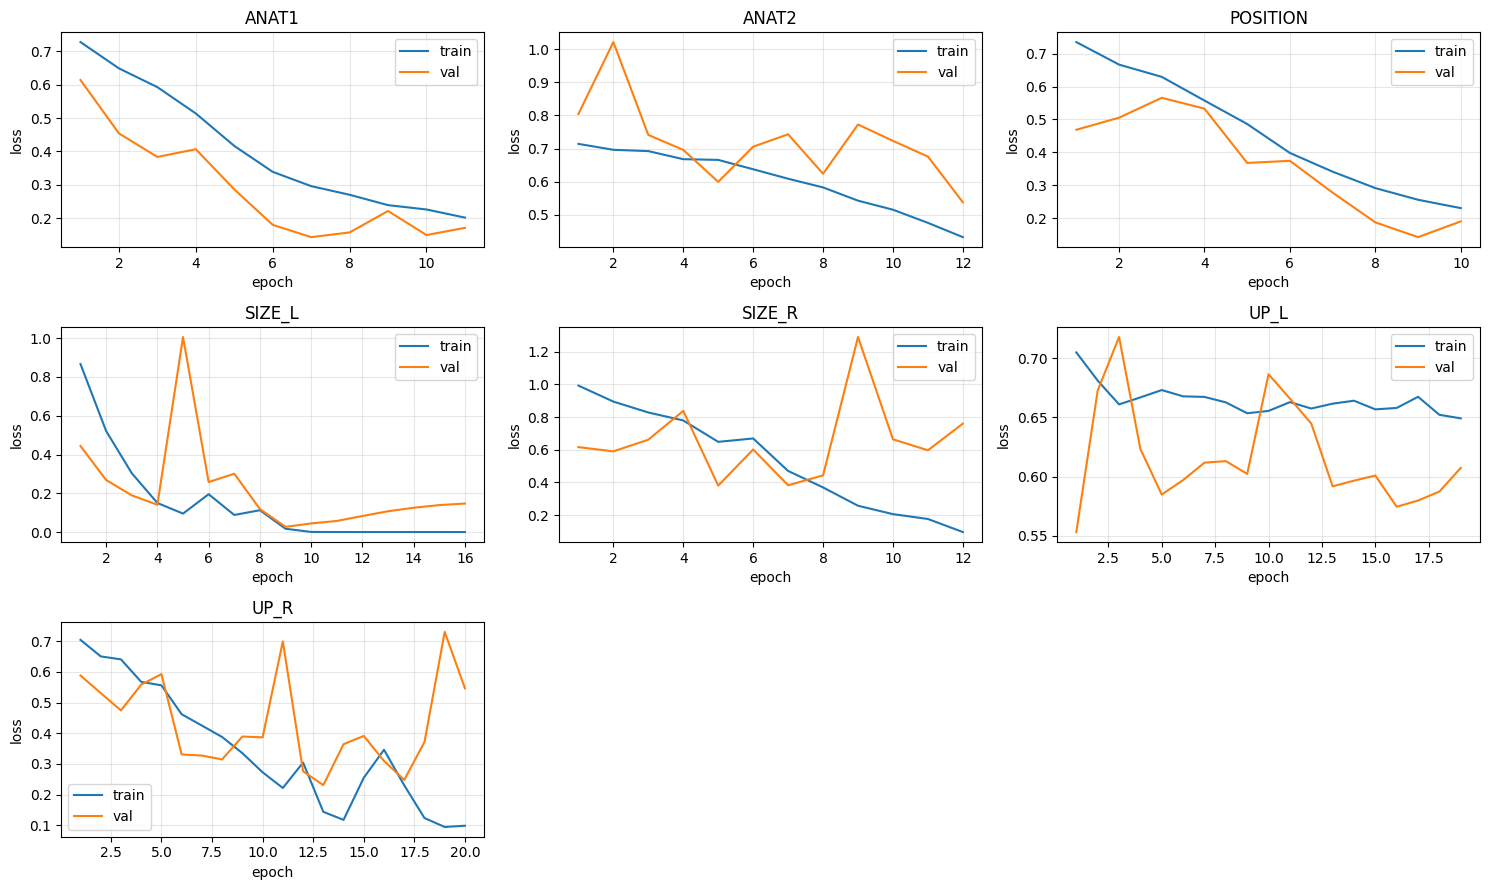

In [1]:
import json, re, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

NB_PATH = Path(r"C:\Users\User\Downloads\postseg_gt_only_fast.ipynb")

nb = json.loads(NB_PATH.read_text(encoding="utf-8"))

lines = []
for cell in nb.get("cells", []):
    for out in cell.get("outputs", []):
        text = ""
        if "text" in out:
            t = out["text"]
            text = "".join(t) if isinstance(t, list) else str(t)
        elif isinstance(out.get("data"), dict) and "text/plain" in out["data"]:
            t = out["data"]["text/plain"]
            text = "".join(t) if isinstance(t, list) else str(t)
        if text:
            lines.extend(text.splitlines())

records = []
pat_size_up = re.compile(r'\[(SIZE_L|SIZE_R|UP_L|UP_R)\]\[E(\d+)\]\s*tr_loss=([0-9.]+)\s*va_loss=([0-9.]+)')
pat_pos_anat = re.compile(r'\[(POSITION|ANAT1|ANAT2)\]\s*ep\s*(\d+).*?train loss\s*([0-9.]+).*?val loss\s*([0-9.]+)', re.IGNORECASE)

for line in lines:
    m = pat_size_up.search(line)
    if m:
        head, ep, tr, va = m.group(1), int(m.group(2)), float(m.group(3)), float(m.group(4))
        records.append({"head": head, "epoch": ep, "train_loss": tr, "val_loss": va})
        continue
    m = pat_pos_anat.search(line)
    if m:
        head, ep, tr, va = m.group(1).upper(), int(m.group(2)), float(m.group(3)), float(m.group(4))
        records.append({"head": head, "epoch": ep, "train_loss": tr, "val_loss": va})

df = pd.DataFrame(records)
if df.empty:
    print("No loss logs found in notebook outputs. (Maybe outputs were cleared?)")
else:
    df = df.sort_values(["head", "epoch"])
    out_csv = NB_PATH.with_suffix(".losses.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    heads = sorted(df["head"].unique())
    cols = 3
    rows = math.ceil(len(heads) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3), squeeze=False)

    for ax, head in zip(axes.ravel(), heads):
        sub = df[df["head"] == head]
        ax.plot(sub["epoch"], sub["train_loss"], label="train")
        ax.plot(sub["epoch"], sub["val_loss"], label="val")
        ax.set_title(head)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # hide unused axes
    for ax in axes.ravel()[len(heads):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
